In [1]:
# Import libraries
import pandas as pd
import numpy as np

In [2]:
from google.colab import files
uploaded = files.upload()

print("Uploaded files:")
for name in uploaded.keys():
    print(" -", name)

Saving PURPOSE OF VISIT(1993-2024).xlsx to PURPOSE OF VISIT(1993-2024).xlsx
Saving Tourist Arrival and Average Length of Stay (1964-2014).xlsx to Tourist Arrival and Average Length of Stay (1964-2014).xlsx
Saving TOURIST ARRIVAL BY MONTH (1995-2024).xlsx to TOURIST ARRIVAL BY MONTH (1995-2024).xlsx
Saving Tourist Arrival by Year (1996-2024).xlsx to Tourist Arrival by Year (1996-2024).xlsx
Uploaded files:
 - PURPOSE OF VISIT(1993-2024).xlsx
 - Tourist Arrival and Average Length of Stay (1964-2014).xlsx
 - TOURIST ARRIVAL BY MONTH (1995-2024).xlsx
 - Tourist Arrival by Year (1996-2024).xlsx


**CLEAN MONTHLY ARRIVALS**

In [3]:
# Load the raw Excel file
monthly_df = pd.read_excel(
    '/content/TOURIST ARRIVAL BY MONTH (1995-2024).xlsx',
    sheet_name='Append1'
)

print("Raw data:")
monthly_df.head()

Raw data:


,Year,Jan.,Feb.,Mar.,Apr.,May,Jun.,Jul.,Aug.,Sep.,Oct.,Nov.,Dec.,Total
0,1995,22207,28240,34219,33994,27843,25650,23980,27686,30569,46845,35782,26380,363395
1,1996,27886,29676,39336,36331,29728,26749,22684,29080,32181,47314,37650,34998,393613
2,1997,25585,32861,43177,35229,33456,26367,26091,35549,31981,56272,40173,35116,421857
3,1998,28822,37956,41338,41087,35814,29181,27895,36174,39664,62487,47403,35863,463684
4,1999,29752,38134,46218,40774,42712,31049,27193,38449,44117,66543,48865,37698,491504


In [4]:
# Remove completely empty rows
monthly_df = monthly_df.dropna(how='all')

# Remove completely empty columns
monthly_df = monthly_df.dropna(axis=1, how='all')

# Remove extra spaces from column names
monthly_df.columns = monthly_df.columns.str.strip()

print("After removing empty rows and columns:")
monthly_df.head()

After removing empty rows and columns:


,Year,Jan.,Feb.,Mar.,Apr.,May,Jun.,Jul.,Aug.,Sep.,Oct.,Nov.,Dec.,Total
0,1995,22207,28240,34219,33994,27843,25650,23980,27686,30569,46845,35782,26380,363395
1,1996,27886,29676,39336,36331,29728,26749,22684,29080,32181,47314,37650,34998,393613
2,1997,25585,32861,43177,35229,33456,26367,26091,35549,31981,56272,40173,35116,421857
3,1998,28822,37956,41338,41087,35814,29181,27895,36174,39664,62487,47403,35863,463684
4,1999,29752,38134,46218,40774,42712,31049,27193,38449,44117,66543,48865,37698,491504


In [5]:
# Give columns simple clean names
monthly_df.columns = [
    'Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Total'
]

print("After renaming columns:")
monthly_df.head()

After renaming columns:


,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Total
0,1995,22207,28240,34219,33994,27843,25650,23980,27686,30569,46845,35782,26380,363395
1,1996,27886,29676,39336,36331,29728,26749,22684,29080,32181,47314,37650,34998,393613
2,1997,25585,32861,43177,35229,33456,26367,26091,35549,31981,56272,40173,35116,421857
3,1998,28822,37956,41338,41087,35814,29181,27895,36174,39664,62487,47403,35863,463684
4,1999,29752,38134,46218,40774,42712,31049,27193,38449,44117,66543,48865,37698,491504


In [6]:
# Remove rows where Year is not a real year number
# Sometimes Excel has hidden title rows or footnotes inside the data
monthly_df = monthly_df[
    pd.to_numeric(monthly_df['Year'], errors='coerce').notna()
]

# Convert Year to integer so it shows as 1995 not 1995.0
monthly_df['Year'] = monthly_df['Year'].astype(int)

# Keep only years 1996 to 2024
monthly_df = monthly_df[
    (monthly_df['Year'] >= 1996) &
    (monthly_df['Year'] <= 2024)
]

# Reset row numbers from 0
monthly_df = monthly_df.reset_index(drop=True)

print("After filtering 1996 to 2024:")
monthly_df.head()

After filtering 1996 to 2024:


,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Total
0,1996,27886,29676,39336,36331,29728,26749,22684,29080,32181,47314,37650,34998,393613
1,1997,25585,32861,43177,35229,33456,26367,26091,35549,31981,56272,40173,35116,421857
2,1998,28822,37956,41338,41087,35814,29181,27895,36174,39664,62487,47403,35863,463684
3,1999,29752,38134,46218,40774,42712,31049,27193,38449,44117,66543,48865,37698,491504
4,2000,25307,38959,44944,43635,28363,26933,24480,34670,43523,59195,52993,40644,463646


In [7]:
# Convert all month columns to proper numbers
month_cols = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Total'
]

for col in month_cols:
    monthly_df[col] = pd.to_numeric(
        monthly_df[col], errors='coerce'
    )

print("Missing values check:")
print(monthly_df.isnull().sum())

Missing values check:
Year     0
Jan      0
Feb      0
Mar      0
Apr      0
May      0
Jun      0
Jul      0
Aug      0
Sep      0
Oct      0
Nov      0
Dec      0
Total    0
dtype: int64


In [8]:
# Add COVID dummy column
# This is for SARIMAX model later
# 0 = normal year
# 1 = COVID affected year
monthly_df['covid_dummy'] = 0
monthly_df.loc[monthly_df['Year'] == 2020, 'covid_dummy'] = 1
monthly_df.loc[monthly_df['Year'] == 2021, 'covid_dummy'] = 1

print("Final cleaned monthly data:")
monthly_df

Final cleaned monthly data:


,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Total,covid_dummy
0,1996,27886,29676,39336,36331,29728,26749,22684,29080,32181,47314,37650,34998,393613,0
1,1997,25585,32861,43177,35229,33456,26367,26091,35549,31981,56272,40173,35116,421857,0
2,1998,28822,37956,41338,41087,35814,29181,27895,36174,39664,62487,47403,35863,463684,0
3,1999,29752,38134,46218,40774,42712,31049,27193,38449,44117,66543,48865,37698,491504,0
4,2000,25307,38959,44944,43635,28363,26933,24480,34670,43523,59195,52993,40644,463646,0
5,2001,30454,38680,46709,39083,28345,13030,18329,25322,31170,41245,30282,18588,361237,0
6,2002,17176,20668,28815,21253,19887,17218,16621,21093,23752,35272,28723,24990,275468,0
7,2003,21215,24349,27737,25851,22704,20351,22661,27568,28724,45459,38398,33115,338132,0
8,2004,30988,35631,44290,33514,26802,19793,24860,33162,25496,43373,36381,31007,385297,0
9,2005,25477,20338,29875,23414,25541,22608,23996,36910,36066,51498,41505,38170,375398,0


In [9]:
monthly_df.to_csv('cleaned_monthly_arrivals.csv', index=False)
print("Saved")

Saved


**CLEAN ANNUAL ARRIVALS**

In [10]:
annual_df = pd.read_excel('/content/Tourist Arrival by Year (1996-2024).xlsx',
    sheet_name='Table019 (Page 28)'
)

print("Raw data:")
annual_df.head()

Raw data:


,Year,Third Country,Indian,Total,% Change
0,1996,271101,122512,393613,8.3
1,1997,288419,133438,421857,7.2
2,1998,320455,143229,463684,9.9
3,1999,350843,140661,491504,6.0
4,2000,367731,95915,463646,-5.7


In [11]:
# Remove empty rows and columns
annual_df = annual_df.dropna(how='all')
annual_df = annual_df.dropna(axis=1, how='all')
annual_df.columns = annual_df.columns.str.strip()

# Rename columns
annual_df.columns = [
    'Year', 'Third_Country', 'Indian', 'Total', 'Pct_Change'
]

# Keep only valid year rows
annual_df = annual_df[
    pd.to_numeric(annual_df['Year'], errors='coerce').notna()
]
annual_df['Year'] = annual_df['Year'].astype(int)

# Filter 1995 to 2024
annual_df = annual_df[
    (annual_df['Year'] >= 1996) &
    (annual_df['Year'] <= 2024)
]
annual_df = annual_df.reset_index(drop=True)

# Convert to numbers
for col in ['Third_Country', 'Indian', 'Total', 'Pct_Change']:
    annual_df[col] = pd.to_numeric(
        annual_df[col], errors='coerce'
    )

print("Missing values:")
print(annual_df.isnull().sum())

Missing values:
Year             0
Third_Country    0
Indian           0
Total            0
Pct_Change       0
dtype: int64


In [12]:
# No covid dummy needed here
# This file is for analysis graphs only, not forecasting

print("Final cleaned annual data:")
annual_df

Final cleaned annual data:


,Year,Third_Country,Indian,Total,Pct_Change
0,1996,271101,122512,393613,8.30
1,1997,288419,133438,421857,7.20
2,1998,320455,143229,463684,9.90
3,1999,350843,140661,491504,6.00
4,2000,367731,95915,463646,-5.70
5,2001,296917,64320,361237,-22.10
6,2002,208691,66777,275468,-23.70
7,2003,251769,86363,338132,22.70
8,2004,294971,90326,385297,13.90
9,2005,278964,96434,375398,-2.60


In [13]:
annual_df.to_csv('cleaned_annual_arrivals.csv', index=False)
print("Saved")

Saved


**PURPOSE OF VISIT**

In [14]:
purpose_df = pd.read_excel(
    '/content/PURPOSE OF VISIT(1993-2024).xlsx',
    sheet_name='Append1'
)

print("Raw data - notice two rows per year:")
purpose_df.head(8)

Raw data - notice two rows per year:


,Year,Holiday Pleasure,Trekking &\nMountaineering,Business,Pilgrimage,Official,Conv./ Conf.,Others,Not Specified,Total,Not\nSpecified
0,1993.0,170279.0,69619.0,19495,10429.0,15812.0,5367.0,2566,-,293567,NaN
1,NaN,-58.0,-23.7,-6.6,-3.6,-5.4,-1.8,-0.9,NaN,-100,NaN
2,1994.0,168155.0,76865.0,23522,5475.0,20431.0,5361.0,26722,-,326531,NaN
3,NaN,-51.5,-23.5,-7.2,-1.7,-6.3,-1.6,-8.2,NaN,-100,NaN
4,1995.0,183207.0,84787.0,21829,5257.0,20090.0,5272.0,42953,-,363395,NaN
5,NaN,-50.4,-23.3,-6,-1.4,-5.5,-1.5,-11.8,NaN,-100,NaN
6,1996.0,209377.0,88945.0,25079,4802.0,20191.0,6054.0,39165,-,393613,NaN
7,NaN,-53.2,-22.6,-6.4,-1.2,-5.1,-1.5,-10,NaN,-100,NaN


In [15]:
# Remove empty rows and columns
purpose_df = purpose_df.dropna(how='all')
purpose_df = purpose_df.dropna(axis=1, how='all')
purpose_df.columns = purpose_df.columns.str.strip()

# Rename all columns
purpose_df.columns = [
    'Year', 'Holiday', 'Trekking', 'Business',
    'Pilgrimage', 'Official', 'Conference',
    'Others', 'Not_Specified', 'Total', 'Extra'
]

print("After renaming:")
purpose_df.head(6)

After renaming:


,Year,Holiday,Trekking,Business,Pilgrimage,Official,Conference,Others,Not_Specified,Total,Extra
0,1993.0,170279.0,69619.0,19495,10429.0,15812.0,5367.0,2566,-,293567,NaN
1,NaN,-58.0,-23.7,-6.6,-3.6,-5.4,-1.8,-0.9,NaN,-100,NaN
2,1994.0,168155.0,76865.0,23522,5475.0,20431.0,5361.0,26722,-,326531,NaN
3,NaN,-51.5,-23.5,-7.2,-1.7,-6.3,-1.6,-8.2,NaN,-100,NaN
4,1995.0,183207.0,84787.0,21829,5257.0,20090.0,5272.0,42953,-,363395,NaN
5,NaN,-50.4,-23.3,-6,-1.4,-5.5,-1.5,-11.8,NaN,-100,NaN


In [16]:
# Remove the percentage rows
# The percentage rows have an empty Year column
# So filtering for valid years automatically removes them
purpose_df = purpose_df[
    pd.to_numeric(purpose_df['Year'], errors='coerce').notna()
]
purpose_df['Year'] = purpose_df['Year'].astype(int)

# Filter 1995 to 2024
purpose_df = purpose_df[
    (purpose_df['Year'] >= 1996) &
    (purpose_df['Year'] <= 2024)
]
purpose_df = purpose_df.reset_index(drop=True)

print("After removing percentage rows:")
print("Rows remaining:", len(purpose_df))
purpose_df.head()

After removing percentage rows:
Rows remaining: 29


,Year,Holiday,Trekking,Business,Pilgrimage,Official,Conference,Others,Not_Specified,Total,Extra
0,1996,209377.0,88945.0,25079,4802.0,20191.0,6054.0,39165,-,393613,NaN
1,1997,249360.0,91525.0,27409,4068.0,24106.0,5824.0,19565,-,421857,NaN
2,1998,261347.0,112644.0,24954,16164.0,22123.0,5181.0,21271,-,463684,NaN
3,1999,290862.0,107960.0,23813,19198.0,24132.0,5965.0,19574,-,491504,NaN
4,2000,255889.0,118780.0,29454,15801.0,20832.0,5599.0,17291,-,463646,NaN


In [17]:
# Clean number columns
# Some cells have commas like 21,066
# Some cells have dashes which become NaN
number_cols = [
    'Holiday', 'Trekking', 'Business',
    'Pilgrimage', 'Official', 'Conference',
    'Others', 'Total'
]

for col in number_cols:
    purpose_df[col] = purpose_df[col].astype(str)
    purpose_df[col] = purpose_df[col].str.replace(
        ',', '', regex=False
    )
    purpose_df[col] = purpose_df[col].str.strip()
    purpose_df[col] = pd.to_numeric(
        purpose_df[col], errors='coerce'
    )

print("After cleaning numbers:")
purpose_df.head()

After cleaning numbers:


,Year,Holiday,Trekking,Business,Pilgrimage,Official,Conference,Others,Not_Specified,Total,Extra
0,1996,209377.0,88945.0,25079.0,4802.0,20191.0,6054.0,39165,-,393613,NaN
1,1997,249360.0,91525.0,27409.0,4068.0,24106.0,5824.0,19565,-,421857,NaN
2,1998,261347.0,112644.0,24954.0,16164.0,22123.0,5181.0,21271,-,463684,NaN
3,1999,290862.0,107960.0,23813.0,19198.0,24132.0,5965.0,19574,-,491504,NaN
4,2000,255889.0,118780.0,29454.0,15801.0,20832.0,5599.0,17291,-,463646,NaN


In [18]:
# Drop columns we do not need
purpose_df = purpose_df.drop(
    columns=['Not_Specified', 'Extra'],
    errors='ignore'
)

print("After dropping unneeded columns:")
purpose_df.head()

After dropping unneeded columns:


,Year,Holiday,Trekking,Business,Pilgrimage,Official,Conference,Others,Total
0,1996,209377.0,88945.0,25079.0,4802.0,20191.0,6054.0,39165,393613
1,1997,249360.0,91525.0,27409.0,4068.0,24106.0,5824.0,19565,421857
2,1998,261347.0,112644.0,24954.0,16164.0,22123.0,5181.0,21271,463684
3,1999,290862.0,107960.0,23813.0,19198.0,24132.0,5965.0,19574,491504
4,2000,255889.0,118780.0,29454.0,15801.0,20832.0,5599.0,17291,463646


In [19]:

# YOUR FIX: Fill Business, Official, Conference
# with 0 for all years

# REASON: From 2017 onwards the government stopped
# separately counting Business, Official and Conference.
# They were all merged into the Others column.
# Putting 0 prevents double counting.
# For 2020 to 2024 the Others column also needs filling
# so that each row adds up to the Total correctly.


# Fill Business, Official, Conference with 0 for all years
purpose_df['Business']   = purpose_df['Business'].fillna(0)
purpose_df['Official']   = purpose_df['Official'].fillna(0)
purpose_df['Conference'] = purpose_df['Conference'].fillna(0)

print("After filling Business, Official, Conference with 0:")
purpose_df[['Year', 'Business', 'Official',
            'Conference', 'Others', 'Total']].tail(10)

After filling Business, Official, Conference with 0:


,Year,Business,Official,Conference,Others,Total
19,2015,20876.0,21479.0,9038.0,77354,538970
20,2016,24322.0,21310.0,12801.0,55797,753002
21,2017,0.0,0.0,0.0,65815,940218
22,2018,0.0,0.0,0.0,112357,1173072
23,2019,0.0,0.0,0.0,49301,1197191
24,2020,0.0,0.0,0.0,26460,230085
25,2021,0.0,0.0,0.0,23398,150962
26,2022,0.0,0.0,0.0,76202,614869
27,2023,0.0,0.0,0.0,93370,1014882
28,2024,0.0,0.0,0.0,112460,1147548


In [20]:
# Fill Others for 2020 to 2024 with the correct values
# so each row adds up to the Total column correctly
others_values = {
    2020: 26460,
    2021: 23398,
    2022: 76202,
    2023: 93370,
    2024: 112460
}

for year, value in others_values.items():
    purpose_df.loc[
        purpose_df['Year'] == year, 'Others'
    ] = value

print("After filling Others for 2020 to 2024:")
purpose_df[['Year', 'Holiday', 'Trekking',
            'Pilgrimage', 'Others', 'Total']].tail(8)

After filling Others for 2020 to 2024:


,Year,Holiday,Trekking,Pilgrimage,Others,Total
21,2017,658153.0,75217.0,141033.0,65815,940218
22,2018,703843.0,187692.0,169180.0,112357,1173072
23,2019,778173.0,197786.0,171937.0,49301,1197191
24,2020,139202.0,28530.0,35893.0,26460,230085
25,2021,100843.0,15549.0,11172.0,23398,150962
26,2022,397820.0,61701.0,79146.0,76202,614869
27,2023,634301.0,154262.0,132949.0,93370,1014882
28,2024,693119.0,166394.0,175575.0,112460,1147548


In [21]:
# Verify each row adds up to Total correctly
purpose_df['Row_Sum'] = (
    purpose_df['Holiday'] +
    purpose_df['Trekking'] +
    purpose_df['Business'] +
    purpose_df['Pilgrimage'] +
    purpose_df['Official'] +
    purpose_df['Conference'] +
    purpose_df['Others']
)

purpose_df['Matches_Total'] = (
    abs(purpose_df['Row_Sum'] - purpose_df['Total']) < 100
)

print("Row sum verification:")
print(purpose_df[['Year', 'Total',
                  'Row_Sum', 'Matches_Total']].to_string())

Row sum verification:
    Year    Total    Row_Sum  Matches_Total
0   1996   393613   393613.0           True
1   1997   421857   421857.0           True
2   1998   463684   463684.0           True
3   1999   491504   491504.0           True
4   2000   463646   463646.0           True
5   2001   361237   361237.0           True
6   2002   275468   275468.0           True
7   2003   338132   338132.0           True
8   2004   385297   385297.0           True
9   2005   375398   375398.0           True
10  2006   383926   383926.0           True
11  2007   526705   504549.0          False
12  2008   500277   470748.0          False
13  2009   509956   469858.0          False
14  2010   602867   545216.0          False
15  2011   736215   665824.0          False
16  2012   803092   711927.0          False
17  2013   797616   724234.0          False
18  2014   790118   715848.0          False
19  2015   538970   538970.0           True
20  2016   753002   753001.0           True
21  2017  

In [22]:
# Drop the helper columns we used for checking
purpose_df = purpose_df.drop(
    columns=['Row_Sum', 'Matches_Total']
)

print("Final cleaned purpose of visit data:")
purpose_df

Final cleaned purpose of visit data:


,Year,Holiday,Trekking,Business,Pilgrimage,Official,Conference,Others,Total
0,1996,209377.0,88945.0,25079.0,4802.0,20191.0,6054.0,39165,393613
1,1997,249360.0,91525.0,27409.0,4068.0,24106.0,5824.0,19565,421857
2,1998,261347.0,112644.0,24954.0,16164.0,22123.0,5181.0,21271,463684
3,1999,290862.0,107960.0,23813.0,19198.0,24132.0,5965.0,19574,491504
4,2000,255889.0,118780.0,29454.0,15801.0,20832.0,5599.0,17291,463646
5,2001,187022.0,100828.0,18528.0,13816.0,18727.0,0.0,22316,361237
6,2002,110143.0,59279.0,16990.0,12366.0,17783.0,0.0,58907,275468
7,2003,97904.0,65721.0,19387.0,21395.0,21967.0,0.0,111758,338132
8,2004,167262.0,69442.0,13948.0,45664.0,17088.0,0.0,71893,385297
9,2005,160259.0,61488.0,21992.0,47621.0,16859.0,0.0,67179,375398


In [23]:
purpose_df.to_csv('cleaned_purpose_of_visit.csv', index=False)
print("Saved")

Saved


In [24]:
# Re-load the raw Excel file for purpose of visit
purpose_df = pd.read_excel(
    '/content/PURPOSE OF VISIT(1993-2024).xlsx',
    sheet_name='Append1'
)

# Remove empty rows and columns
purpose_df = purpose_df.dropna(how='all')
purpose_df = purpose_df.dropna(axis=1, how='all')
purpose_df.columns = purpose_df.columns.str.strip()

# Rename all columns
purpose_df.columns = [
    'Year', 'Holiday', 'Trekking', 'Business',
    'Pilgrimage', 'Official', 'Conference',
    'Others', 'Not_Specified', 'Total', 'Extra'
]

# Remove the percentage rows
purpose_df = purpose_df[
    pd.to_numeric(purpose_df['Year'], errors='coerce').notna()
]
purpose_df['Year'] = purpose_df['Year'].astype(int)

# Filter 1996 to 2024
purpose_df = purpose_df[
    (purpose_df['Year'] >= 1996) &
    (purpose_df['Year'] <= 2024)
]
purpose_df = purpose_df.reset_index(drop=True)

# Clean number columns
number_cols = [
    'Holiday', 'Trekking', 'Business',
    'Pilgrimage', 'Official', 'Conference',
    'Others', 'Total'
]

for col in number_cols:
    purpose_df[col] = purpose_df[col].astype(str)
    purpose_df[col] = purpose_df[col].str.replace(
        ',', '', regex=False
    )
    purpose_df[col] = purpose_df[col].str.strip()
    purpose_df[col] = pd.to_numeric(
        purpose_df[col], errors='coerce'
    )

# Drop columns we do not need
purpose_df = purpose_df.drop(
    columns=['Not_Specified', 'Extra'],
    errors='ignore'
)

# Fill Business, Official, Conference with 0 for all years (keeping this)
purpose_df['Business']   = purpose_df['Business'].fillna(0)
purpose_df['Official']   = purpose_df['Official'].fillna(0)
purpose_df['Conference'] = purpose_df['Conference'].fillna(0)

# Manually fill Others for 2020 to 2024 (keeping this as it's explicit values)
others_values = {
    2020: 26460,
    2021: 23398,
    2022: 76202,
    2023: 93370,
    2024: 112460
}

for year, value in others_values.items():
    purpose_df.loc[
        purpose_df['Year'] == year, 'Others'
    ] = value

print("Purpose of Visit data after re-cleaning (without dynamic 'Others' adjustment):")
display(purpose_df.head())


Purpose of Visit data after re-cleaning (without dynamic 'Others' adjustment):


,Year,Holiday,Trekking,Business,Pilgrimage,Official,Conference,Others,Total
0,1996,209377.0,88945.0,25079.0,4802.0,20191.0,6054.0,39165,393613
1,1997,249360.0,91525.0,27409.0,4068.0,24106.0,5824.0,19565,421857
2,1998,261347.0,112644.0,24954.0,16164.0,22123.0,5181.0,21271,463684
3,1999,290862.0,107960.0,23813.0,19198.0,24132.0,5965.0,19574,491504
4,2000,255889.0,118780.0,29454.0,15801.0,20832.0,5599.0,17291,463646


In [25]:
# Re-verify each row adds up to Total correctly, without making adjustments
purpose_df['Row_Sum'] = (
    purpose_df['Holiday'] +
    purpose_df['Trekking'] +
    purpose_df['Business'] +
    purpose_df['Pilgrimage'] +
    purpose_df['Official'] +
    purpose_df['Conference'] +
    purpose_df['Others']
)

purpose_df['Matches_Total'] = (
    abs(purpose_df['Row_Sum'] - purpose_df['Total']) < 100 # Use a small tolerance for comparison
)

print("Row sum verification (showing original data counting):")
print(purpose_df[['Year', 'Total', 'Row_Sum', 'Matches_Total']].to_string())


Row sum verification (showing original data counting):
    Year    Total    Row_Sum  Matches_Total
0   1996   393613   393613.0           True
1   1997   421857   421857.0           True
2   1998   463684   463684.0           True
3   1999   491504   491504.0           True
4   2000   463646   463646.0           True
5   2001   361237   361237.0           True
6   2002   275468   275468.0           True
7   2003   338132   338132.0           True
8   2004   385297   385297.0           True
9   2005   375398   375398.0           True
10  2006   383926   383926.0           True
11  2007   526705   504549.0          False
12  2008   500277   470748.0          False
13  2009   509956   469858.0          False
14  2010   602867   545216.0          False
15  2011   736215   665824.0          False
16  2012   803092   711927.0          False
17  2013   797616   724234.0          False
18  2014   790118   715848.0          False
19  2015   538970   538970.0           True
20  2016   753002   7

In [26]:
# Drop the helper columns we used for checking
purpose_df = purpose_df.drop(
    columns=['Row_Sum', 'Matches_Total']
)

print("Final cleaned purpose of visit data, with original Others counts:")
display(purpose_df.head())

Final cleaned purpose of visit data, with original Others counts:


,Year,Holiday,Trekking,Business,Pilgrimage,Official,Conference,Others,Total
0,1996,209377.0,88945.0,25079.0,4802.0,20191.0,6054.0,39165,393613
1,1997,249360.0,91525.0,27409.0,4068.0,24106.0,5824.0,19565,421857
2,1998,261347.0,112644.0,24954.0,16164.0,22123.0,5181.0,21271,463684
3,1999,290862.0,107960.0,23813.0,19198.0,24132.0,5965.0,19574,491504
4,2000,255889.0,118780.0,29454.0,15801.0,20832.0,5599.0,17291,463646


**LENGTH OF STAY**

In [27]:
stay_df = pd.read_excel(
    '/content/Tourist Arrival and Average Length of Stay (1964-2014).xlsx',
    sheet_name='Table013 (Page 19-20)'
)

print("Raw data:")
stay_df.head()

Raw data:


,Year,Total Number,Annual Growth\nRate (%),By Air Number,By Air Percent,By Land Number,By Land Percent,Average Length\nof Stay
0,1964,"9,526",30.9,"8,435",88.5,"1,091",11.5,NaN
1,1965,"9,388",-1.4,"8,303",88.4,"1,085",11.6,NaN
2,1966,"12,567",33.9,"11,206",89.2,"1,361",10.8,NaN
3,1967,"18,093",44.0,"15,064",83.3,"3,029",16.7,NaN
4,1968,"24,209",33.8,"19,717",81.4,"4,492",18.6,NaN


In [28]:
# Remove empty rows and columns
stay_df = stay_df.dropna(how='all')
stay_df = stay_df.dropna(axis=1, how='all')
stay_df.columns = stay_df.columns.str.strip()

# Rename columns
stay_df.columns = [
    'Year', 'Total', 'Growth_Rate',
    'By_Air_Number', 'By_Air_Pct',
    'By_Land_Number', 'By_Land_Pct',
    'Avg_Stay_Days'
]

print("After renaming:")
stay_df.head()

After renaming:


,Year,Total,Growth_Rate,By_Air_Number,By_Air_Pct,By_Land_Number,By_Land_Pct,Avg_Stay_Days
0,1964,"9,526",30.9,"8,435",88.5,"1,091",11.5,NaN
1,1965,"9,388",-1.4,"8,303",88.4,"1,085",11.6,NaN
2,1966,"12,567",33.9,"11,206",89.2,"1,361",10.8,NaN
3,1967,"18,093",44.0,"15,064",83.3,"3,029",16.7,NaN
4,1968,"24,209",33.8,"19,717",81.4,"4,492",18.6,NaN


In [29]:
# Keep only valid year rows
stay_df = stay_df[
    pd.to_numeric(stay_df['Year'], errors='coerce').notna()
]
stay_df['Year'] = stay_df['Year'].astype(int)

# Filter 1995 to 2024
stay_df = stay_df[
    (stay_df['Year'] >= 1996) &
    (stay_df['Year'] <= 2024)
]
stay_df = stay_df.reset_index(drop=True)

# Clean number columns
# Older rows have commas like 363,395
number_cols = [
    'Total', 'Growth_Rate',
    'By_Air_Number', 'By_Air_Pct',
    'By_Land_Number', 'By_Land_Pct',
    'Avg_Stay_Days'
]

for col in number_cols:
    stay_df[col] = stay_df[col].astype(str)
    stay_df[col] = stay_df[col].str.replace(
        ',', '', regex=False
    )
    stay_df[col] = stay_df[col].str.strip()
    stay_df[col] = pd.to_numeric(
        stay_df[col], errors='coerce'
    )

print("Missing values:")
print(stay_df.isnull().sum())

Missing values:
Year              0
Total             0
Growth_Rate       0
By_Air_Number     0
By_Air_Pct        0
By_Land_Number    0
By_Land_Pct       0
Avg_Stay_Days     0
dtype: int64


In [30]:
print("Final cleaned stay data:")
stay_df

Final cleaned stay data:


,Year,Total,Growth_Rate,By_Air_Number,By_Air_Pct,By_Land_Number,By_Land_Pct,Avg_Stay_Days
0,1996,393613,8.30,343246,87.20,50367,12.80,13.50
1,1997,421857,7.20,371145,88.00,50712,12.00,10.49
2,1998,463684,9.90,398008,85.80,65676,14.20,10.76
3,1999,491504,6.00,421243,85.70,70261,14.30,12.28
4,2000,463646,-5.70,376914,81.30,86732,18.70,11.88
5,2001,361237,-22.10,299514,82.90,61723,17.10,11.93
6,2002,275468,-23.70,218660,79.40,56808,20.60,7.92
7,2003,338132,22.70,275438,81.50,62694,18.50,9.60
8,2004,385297,13.90,297335,77.20,87962,22.80,13.51
9,2005,375398,-2.60,277346,73.90,98052,26.10,9.09


In [31]:
stay_df.to_csv('cleaned_length_of_stay.csv', index=False)
print("Saved")

Saved


**Proper Monthly Time Series for Forecasting**

In [32]:
# MONTHLY TIME SERIES
# Convert the wide table into one row per month
# This is the exact format ARIMA and SARIMAX needs
# 30 years x 12 months = 360 rows total

month_cols = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]

# Empty lists to store values
dates    = []
arrivals = []
dummies  = []

# Go through each year
for _, row in monthly_df.iterrows():
    year = int(row['Year'])

    # Go through each month in that year
    for month_num, month_name in enumerate(month_cols, start=1):

        # Build a proper date like 1995-01-01
        date = pd.Timestamp(year=year, month=month_num, day=1)
        dates.append(date)

        # Add the arrival number for that month
        arrivals.append(row[month_name])

        # Assign COVID dummy at month level
        # January 2020, February 2020, March 2020 = 0 (still normal)
        # April 2020 onwards to December 2021 = 1 (COVID affected)
        if (year == 2020 and month_num >= 4) or (year == 2021):
            dummies.append(1)
        else:
            dummies.append(0)

# Build the dataframe
ts_df = pd.DataFrame({
    'Date'        : dates,
    'Arrivals'    : arrivals,
    'covid_dummy' : dummies
})

# Set Date as index
ts_df = ts_df.set_index('Date')

# Convert arrivals to numbers
ts_df['Arrivals'] = pd.to_numeric(
    ts_df['Arrivals'], errors='coerce'
)

print("Monthly time series:")
ts_df.head(15)

Monthly time series:


,Arrivals,covid_dummy
Date,,
1996-01-01,27886,0
1996-02-01,29676,0
1996-03-01,39336,0
1996-04-01,36331,0
1996-05-01,29728,0
1996-06-01,26749,0
1996-07-01,22684,0
1996-08-01,29080,0
1996-09-01,32181,0


In [33]:
# Check the time series
print("Total rows         :", len(ts_df))
print("Start date         :", ts_df.index[0].strftime('%b %Y'))
print("End date           :", ts_df.index[-1].strftime('%b %Y'))
print("Missing values     :", ts_df['Arrivals'].isnull().sum())
print("Normal months (0)  :", (ts_df['covid_dummy'] == 0).sum())
print("COVID months  (1)  :", (ts_df['covid_dummy'] == 1).sum())

print("\nCOVID affected months:")
ts_df[ts_df['covid_dummy'] == 1]

Total rows         : 348
Start date         : Jan 1996
End date           : Dec 2024
Missing values     : 0
Normal months (0)  : 327
COVID months  (1)  : 21

COVID affected months:


,Arrivals,covid_dummy
Date,,
2020-04-01,14,1
2020-05-01,31,1
2020-06-01,102,1
2020-07-01,196,1
2020-08-01,267,1
2020-09-01,584,1
2020-10-01,2025,1
2020-11-01,1956,1
2020-12-01,4242,1


In [34]:
# Save
ts_df.to_csv('cleaned_monthly_time_series.csv')
print("Saved: cleaned_monthly_time_series.csv")

Saved: cleaned_monthly_time_series.csv


**OUTLIER DETECTION**

In [35]:
# Load the cleaned files from previous step
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# For forecasting
ts_df = pd.read_csv('cleaned_monthly_time_series.csv',
                    index_col='Date', parse_dates=True)

# For analysis graphs
monthly_df  = pd.read_csv('/content/cleaned_monthly_arrivals.csv')
annual_df   = pd.read_csv('/content/cleaned_annual_arrivals.csv')
purpose_df  = pd.read_csv('/content/cleaned_purpose_of_visit.csv')
stay_df     = pd.read_csv('/content/cleaned_length_of_stay.csv')

print("Files loaded successfully")
print("Monthly time series rows:", len(ts_df))
print("First date:", ts_df.index[0])
print("Last date :", ts_df.index[-1])

Files loaded successfully
Monthly time series rows: 348
First date: 1996-01-01 00:00:00
Last date : 2024-12-01 00:00:00


In [36]:
from scipy import stats

# Separate the arrivals series
arrivals = ts_df['Arrivals']

# Calculate Z-Score for every month
z_scores = np.abs(stats.zscore(arrivals))

# Convert z_scores to a pandas Series with the same index as arrivals
z_scores_series = pd.Series(z_scores, index=arrivals.index)

# Any month with Z-Score above 3 is an outlier
threshold = 3.0
outlier_mask = z_scores > threshold

print("OUTLIER DETECTION RESULTS")
print("Total months     :", len(arrivals))
print("Outliers found   :", outlier_mask.sum())
print("\nOutlier months:")
for date, val in arrivals[outlier_mask].items():
    # Retrieve the corresponding z-score using the date index from the new Series
    z = z_scores_series.loc[date]
    print(f"  {date.strftime('%b %Y')} - Arrivals: {val:,.0f}  Z-Score: {z:.2f}")

OUTLIER DETECTION RESULTS
Total months     : 348
Outliers found   : 2

Outlier months:
  Nov 2018 — Arrivals: 147,859  Z-Score: 3.51
  Oct 2019 — Arrivals: 134,096  Z-Score: 3.02


In [37]:
# Replace outliers with 12 month rolling median
# We do not delete them, we smooth them
arrivals_smoothed = arrivals.copy().astype(float)
rolling_median = arrivals.rolling(window=12, min_periods=6, center=True).median()

for date in arrivals[outlier_mask].index:
    original = arrivals_smoothed[date]
    replaced = rolling_median[date]
    arrivals_smoothed[date] = replaced
    print(f"  {date.strftime('%b %Y')}: {original:,.0f} replaced with {replaced:,.0f}")

print("\nMissing values after smoothing:", arrivals_smoothed.isnull().sum())

  Nov 2018: 147,859 replaced with 97,148
  Oct 2019: 134,096 replaced with 93,676

Missing values after smoothing: 0


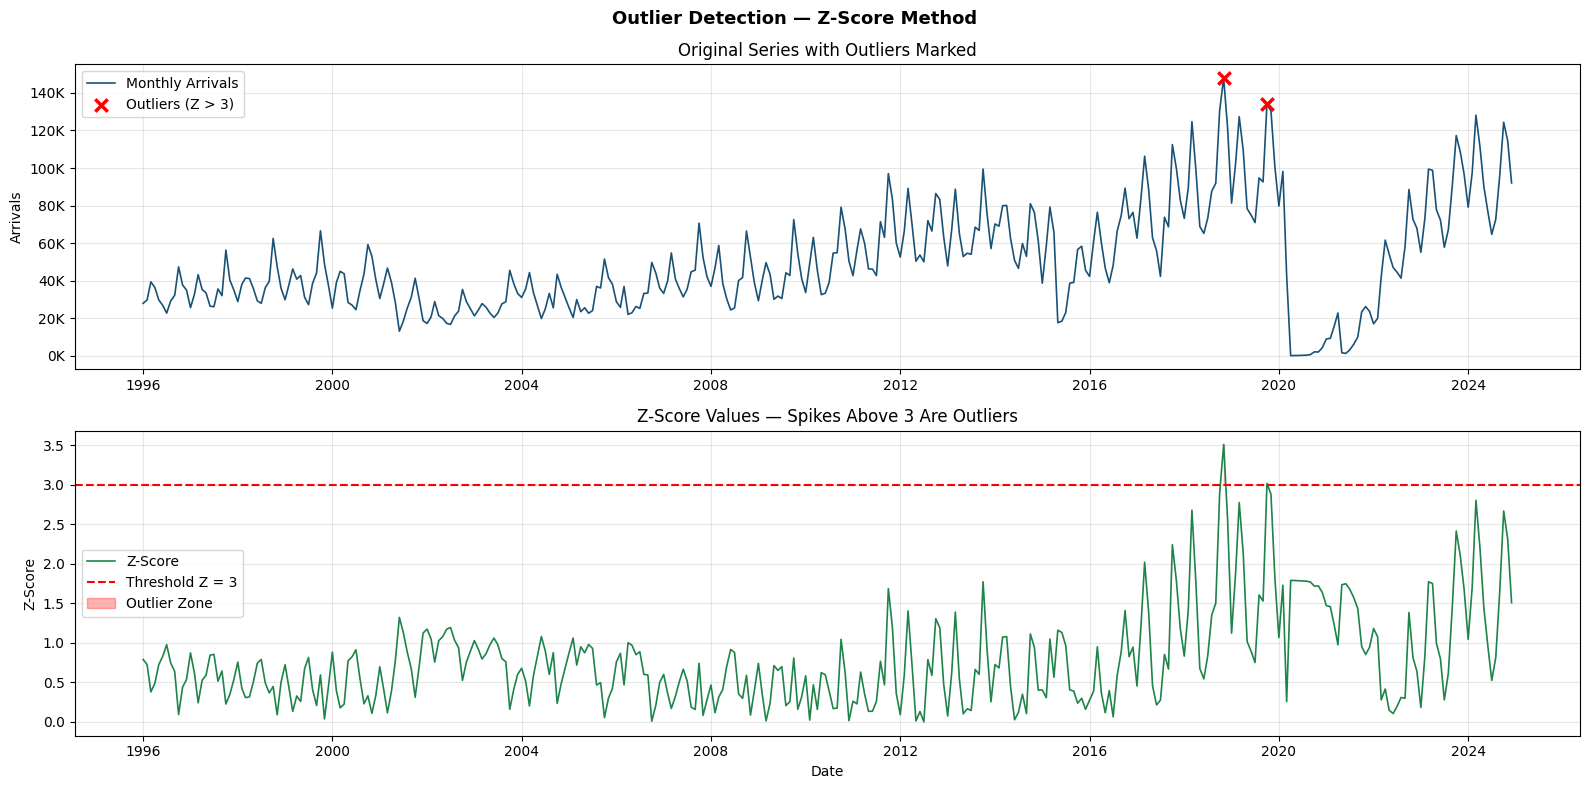

Graph saved


In [38]:
# Graph: Outlier detection
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
fig.suptitle('Outlier Detection — Z-Score Method',
             fontsize=13, fontweight='bold')

# Top panel: series with outliers marked
axes[0].plot(arrivals.index, arrivals.values,
             color='#1a5276', linewidth=1.2,
             label='Monthly Arrivals')
axes[0].scatter(
    arrivals[outlier_mask].index,
    arrivals[outlier_mask].values,
    color='red', s=80, zorder=5,
    marker='x', linewidths=2.5,
    label='Outliers (Z > 3)'
)
axes[0].set_title('Original Series with Outliers Marked')
axes[0].set_ylabel('Arrivals')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K')
)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bottom panel: Z-Score values
axes[1].plot(arrivals.index, z_scores,
             color='#1e8449', linewidth=1.2,
             label='Z-Score')
axes[1].axhline(3.0, color='red', linestyle='--',
                linewidth=1.5,
                label='Threshold Z = 3')
axes[1].fill_between(
    arrivals.index, 3.0, z_scores,
    where=z_scores > 3.0,
    alpha=0.3, color='red',
    label='Outlier Zone'
)
axes[1].set_title('Z-Score Values — Spikes Above 3 Are Outliers')
axes[1].set_ylabel('Z-Score')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('graph1_outlier_detection.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Graph saved")

In [39]:
# Save the smoothed series back into ts_df
ts_df['Arrivals_Smoothed'] = arrivals_smoothed.values

print("Smoothed arrivals added to ts_df")
ts_df.head(10)

Smoothed arrivals added to ts_df


,Arrivals,covid_dummy,Arrivals_Smoothed
Date,,,
1996-01-01,27886,0,27886.0
1996-02-01,29676,0,29676.0
1996-03-01,39336,0,39336.0
1996-04-01,36331,0,36331.0
1996-05-01,29728,0,29728.0
1996-06-01,26749,0,26749.0
1996-07-01,22684,0,22684.0
1996-08-01,29080,0,29080.0
1996-09-01,32181,0,32181.0


**STATIONARITY TEST**

In [40]:
# STATIONARITY TEST - AUGMENTED DICKEY FULLER
# ARIMA and SARIMAX both require stationary data

from statsmodels.tsa.stattools import adfuller

series = ts_df['Arrivals_Smoothed']

def adf_test(series, label):
    result = adfuller(series.dropna(), autolag='AIC')
    is_stationary = result[1] < 0.05
    print(f"\n  ADF Test - {label}")
    print(f"  ADF Statistic  : {result[0]:.4f}")
    print(f"  p-value        : {result[1]:.6f}")
    print(f"  Critical Values:")
    for key, val in result[4].items():
        print(f"    {key} : {val:.4f}")
    print(f"  Result "
          f"{'STATIONARY' if is_stationary else 'NON-STATIONARY'}")
    return is_stationary

print("STATIONARITY TESTS")

# Test 1: Original smoothed series
stat1 = adf_test(series, "Original Smoothed Series")

# Test 2: First differenced
series_diff1 = series.diff(1).dropna()
stat2 = adf_test(series_diff1, "First Differenced (d=1)")

# Test 3: Seasonal differenced
series_diff_s = series.diff(12).dropna()
stat3 = adf_test(series_diff_s, "Seasonal Differenced (D=1, s=12)")

# Test 4: Both differenced together
series_diff_both = series.diff(12).diff(1).dropna()
stat4 = adf_test(series_diff_both,
                 "Seasonal + First Differenced (d=1, D=1)")

print("\n SUMMARY")
print("Original              :", "Stationary" if stat1 else "Non-Stationary")
print("First diff (d=1)      :", "Stationary" if stat2 else "Non-Stationary")
print("Seasonal diff (D=1)   :", "Stationary" if stat3 else "Non-Stationary")
print("Both diff (d=1, D=1)  :", "Stationary" if stat4 else "Non-Stationary")
print("\n SARIMAX will use d=1 and D=1")

STATIONARITY TESTS

  ADF Test — Original Smoothed Series
  ADF Statistic  : -3.6889
  p-value        : 0.004272
  Critical Values:
    1% : -3.4503
    5% : -2.8703
    10% : -2.5715
  Result STATIONARY

  ADF Test — First Differenced (d=1)
  ADF Statistic  : -3.9470
  p-value        : 0.001715
  Critical Values:
    1% : -3.4504
    5% : -2.8704
    10% : -2.5715
  Result STATIONARY

  ADF Test — Seasonal Differenced (D=1, s=12)
  ADF Statistic  : -3.9545
  p-value        : 0.001668
  Critical Values:
    1% : -3.4508
    5% : -2.8705
    10% : -2.5716
  Result STATIONARY

  ADF Test — Seasonal + First Differenced (d=1, D=1)
  ADF Statistic  : -6.2850
  p-value        : 0.000000
  Critical Values:
    1% : -3.4508
    5% : -2.8705
    10% : -2.5716
  Result STATIONARY

 SUMMARY
Original              : Stationary
First diff (d=1)      : Stationary
Seasonal diff (D=1)   : Stationary
Both diff (d=1, D=1)  : Stationary

 SARIMAX will use d=1 and D=1


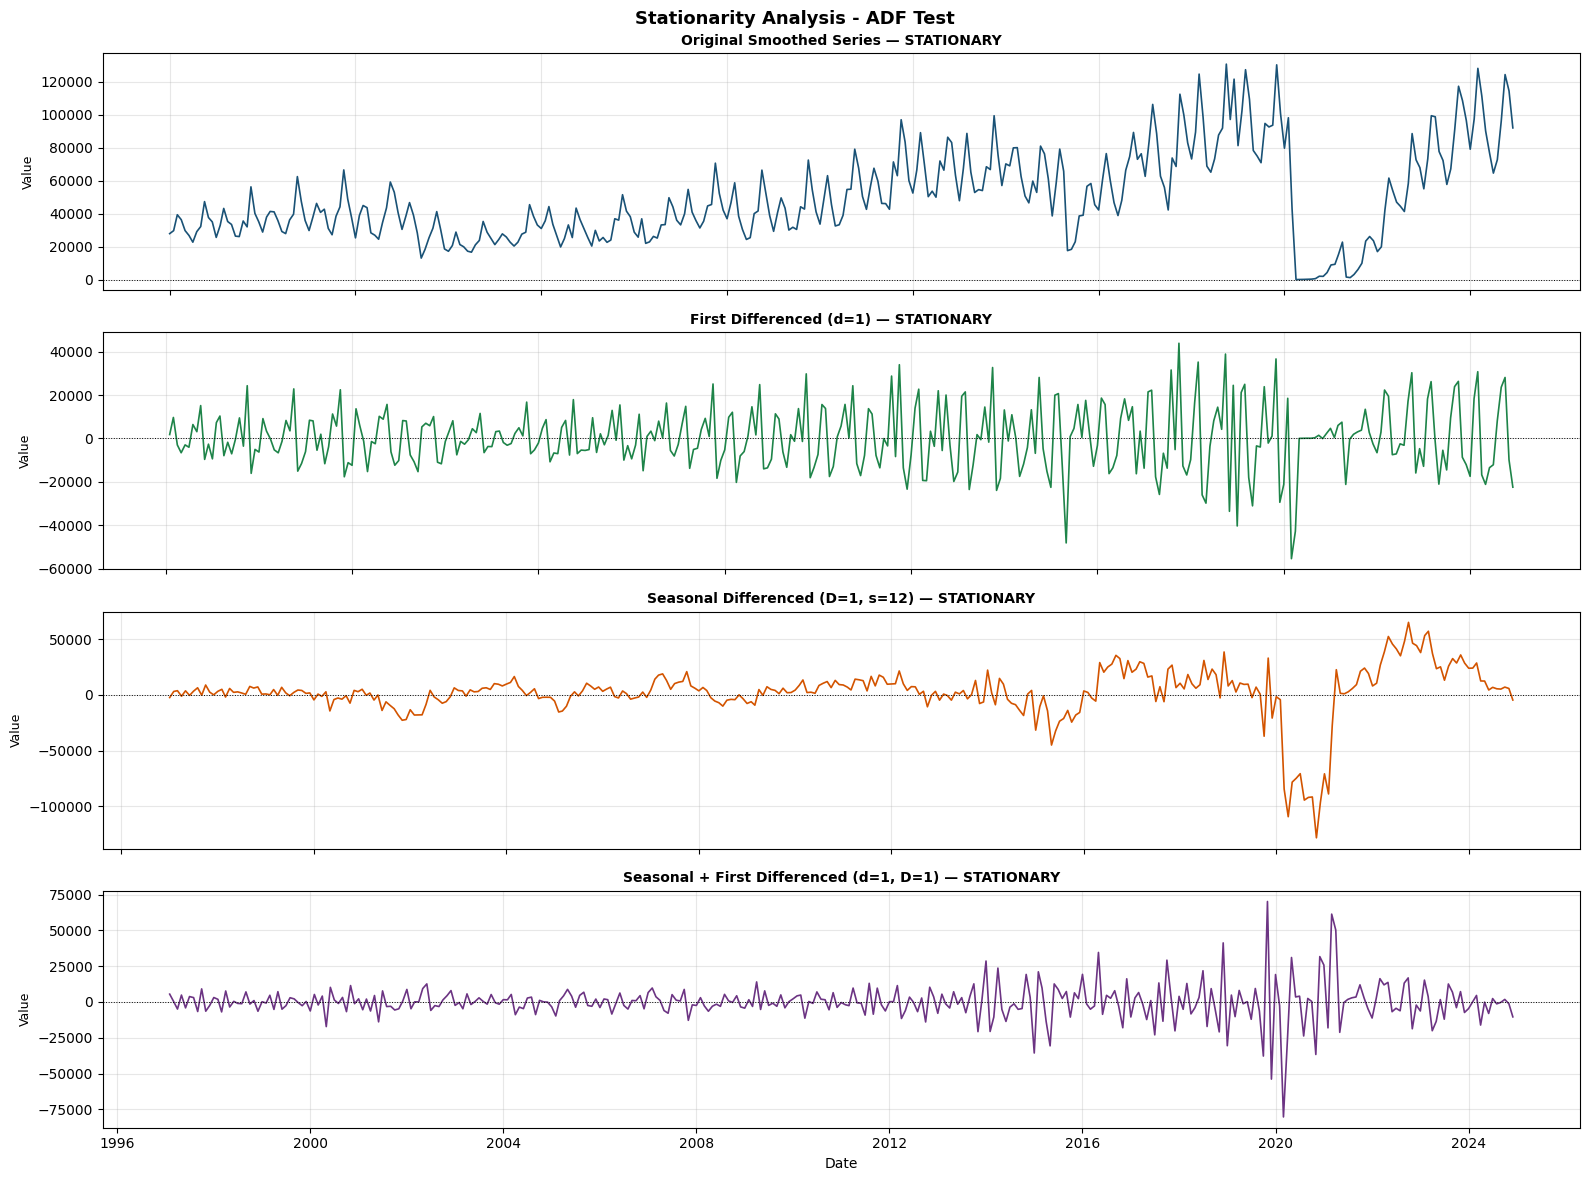

Graph saved


In [86]:
# Graph: Stationarity comparison
fig, axes = plt.subplots(4, 1, figsize=(16, 12))
fig.suptitle('Stationarity Analysis - ADF Test',
             fontsize=13, fontweight='bold')

series_list = [
    (series,           'Original Smoothed Series',
     '#1a5276', stat1),
    (series_diff1,     'First Differenced (d=1)',
     '#1e8449', stat2),
    (series_diff_s,    'Seasonal Differenced (D=1, s=12)',
     '#d35400', stat3),
    (series_diff_both, 'Seasonal + First Differenced (d=1, D=1)',
     '#6c3483', stat4),
]

for i, (s, title, color, is_stat) in enumerate(series_list):
    axes[i].plot(s.index, s.values,
                 color=color, linewidth=1.2)
    axes[i].axhline(0, color='black',
                    linewidth=0.7, linestyle=':')
    status = "STATIONARY" if is_stat else "NON-STATIONARY "
    axes[i].set_title(f'{title} — {status}',
                      fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Value', fontsize=9)
    axes[i].grid(True, alpha=0.3)
    if i < 3:
        axes[i].set_xticklabels([])

axes[3].set_xlabel('Date')
plt.tight_layout()
plt.savefig('graph2_stationarity.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Graph saved")

**EXPLORATORY DATA ANALYSIS (EDA)**

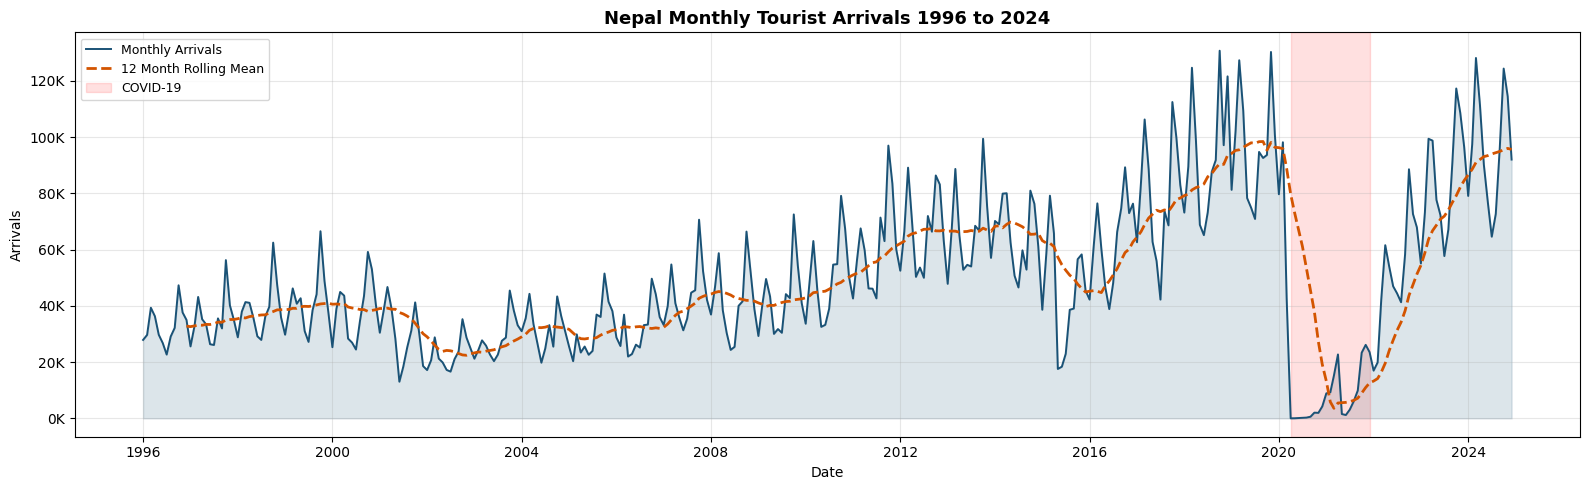

Graph saved


In [42]:
# Monthly Tourist Arrivals Time Series with COVID-19 Intervention Period (1996–2024)
# GRAPH: Full Time Series
# uses cleaned_monthly_time_series.csv this dataset
# The ts_df DataFrame is loaded from the cleaned_monthly_time_series.csv file,
# which was created earlier in the notebook after cleaning and
# transforming the raw monthly arrivals data.
fig, ax = plt.subplots(figsize=(16, 5))

ax.fill_between(series.index, series.values,
                alpha=0.15, color='#1a5276')
ax.plot(series.index, series.values,
        color='#1a5276', linewidth=1.4,
        label='Monthly Arrivals')
ax.plot(series.rolling(12).mean().index,
        series.rolling(12).mean().values,
        color='#d35400', linewidth=2,
        linestyle='--', label='12 Month Rolling Mean')

ax.axvspan(pd.Timestamp('2020-04-01'),
           pd.Timestamp('2021-12-01'),
           alpha=0.12, color='red', label='COVID-19')

ax.set_title('Nepal Monthly Tourist Arrivals 1996 to 2024',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Arrivals')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K')
)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('graph3_full_time_series.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph saved")

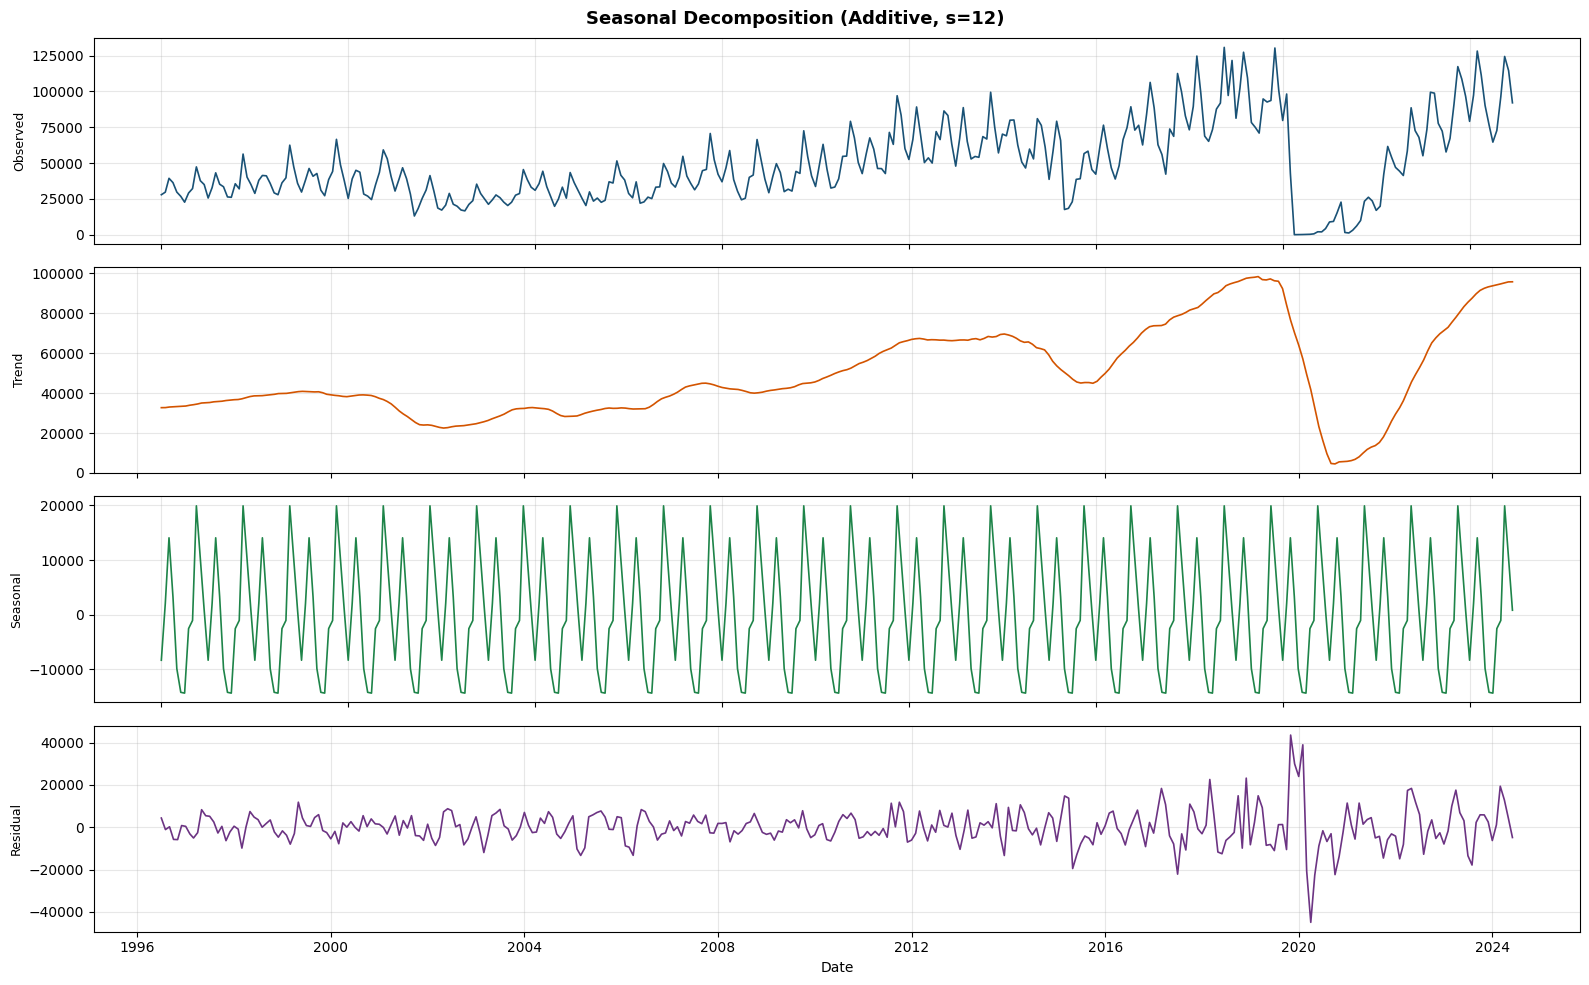

Graph saved


In [43]:
# GRAPH: Seasonal Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(
    series.dropna(), model='additive', period=12
)

fig, axes = plt.subplots(4, 1, figsize=(16, 10))
fig.suptitle('Seasonal Decomposition (Additive, s=12)',
             fontsize=13, fontweight='bold')

parts = [
    (decomp.observed,  'Observed',   '#1a5276'),
    (decomp.trend,     'Trend',      '#d35400'),
    (decomp.seasonal,  'Seasonal',   '#1e8449'),
    (decomp.resid,     'Residual',   '#6c3483'),
]

for i, (data, label, color) in enumerate(parts):
    axes[i].plot(data.index, data.values,
                 color=color, linewidth=1.2)
    axes[i].set_ylabel(label, fontsize=9)
    axes[i].grid(True, alpha=0.3)
    if i < 3:
        axes[i].set_xticklabels([])

axes[3].set_xlabel('Date')
plt.tight_layout()
plt.savefig('graph4_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph saved")

**ACF and PACF**

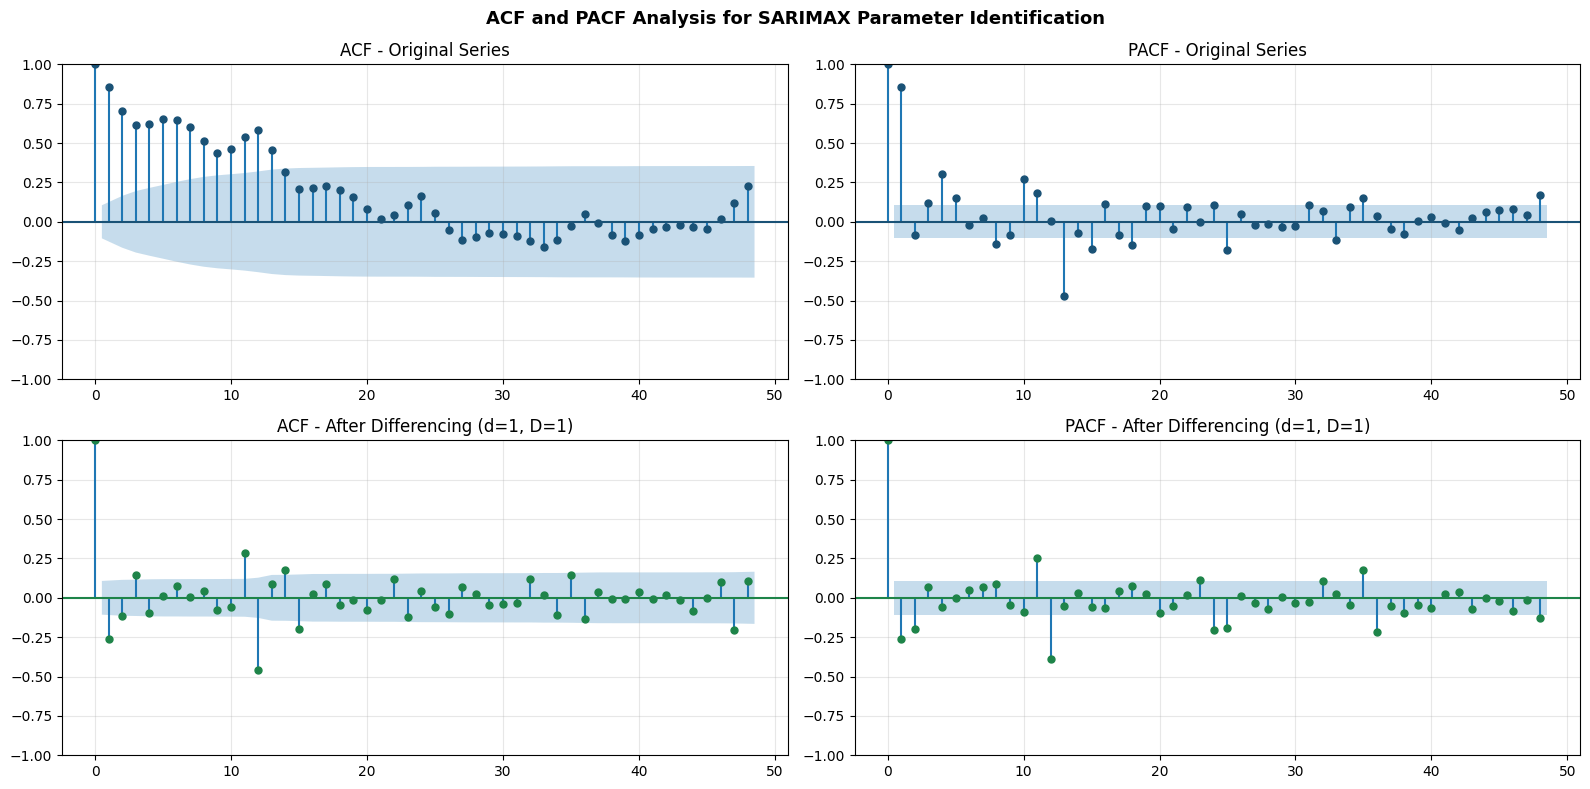

ACF and PACF graph saved successfully!


In [44]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Ensure clean series
series_clean = series.dropna()

# Only apply dropna if differenced series exists
series_diff_clean = series_diff_both.dropna()

# Plot layout
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('ACF and PACF Analysis for SARIMAX Parameter Identification',
             fontsize=13, fontweight='bold')

# 1. ACF - Original Series
plot_acf(series_clean, lags=48, ax=axes[0, 0], color='#1a5276')
axes[0, 0].set_title('ACF - Original Series')
axes[0, 0].grid(True, alpha=0.3)

# 2. PACF - Original Series
plot_pacf(series_clean, lags=48, ax=axes[0, 1], method='ywm', color='#1a5276')
axes[0, 1].set_title('PACF - Original Series')
axes[0, 1].grid(True, alpha=0.3)

# 3. ACF - Differenced Series
plot_acf(series_diff_clean, lags=48, ax=axes[1, 0], color='#1e8449')
axes[1, 0].set_title('ACF - After Differencing (d=1, D=1)')
axes[1, 0].grid(True, alpha=0.3)

# 4. PACF - Differenced Series
plot_pacf(series_diff_clean, lags=48, ax=axes[1, 1], method='ywm', color='#1e8449')
axes[1, 1].set_title('PACF - After Differencing (d=1, D=1)')
axes[1, 1].grid(True, alpha=0.3)

# Final adjustments
plt.tight_layout()
plt.savefig('acf_pacf_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("ACF and PACF graph saved successfully!")

**CROWD INTENSITY HEATMAP**

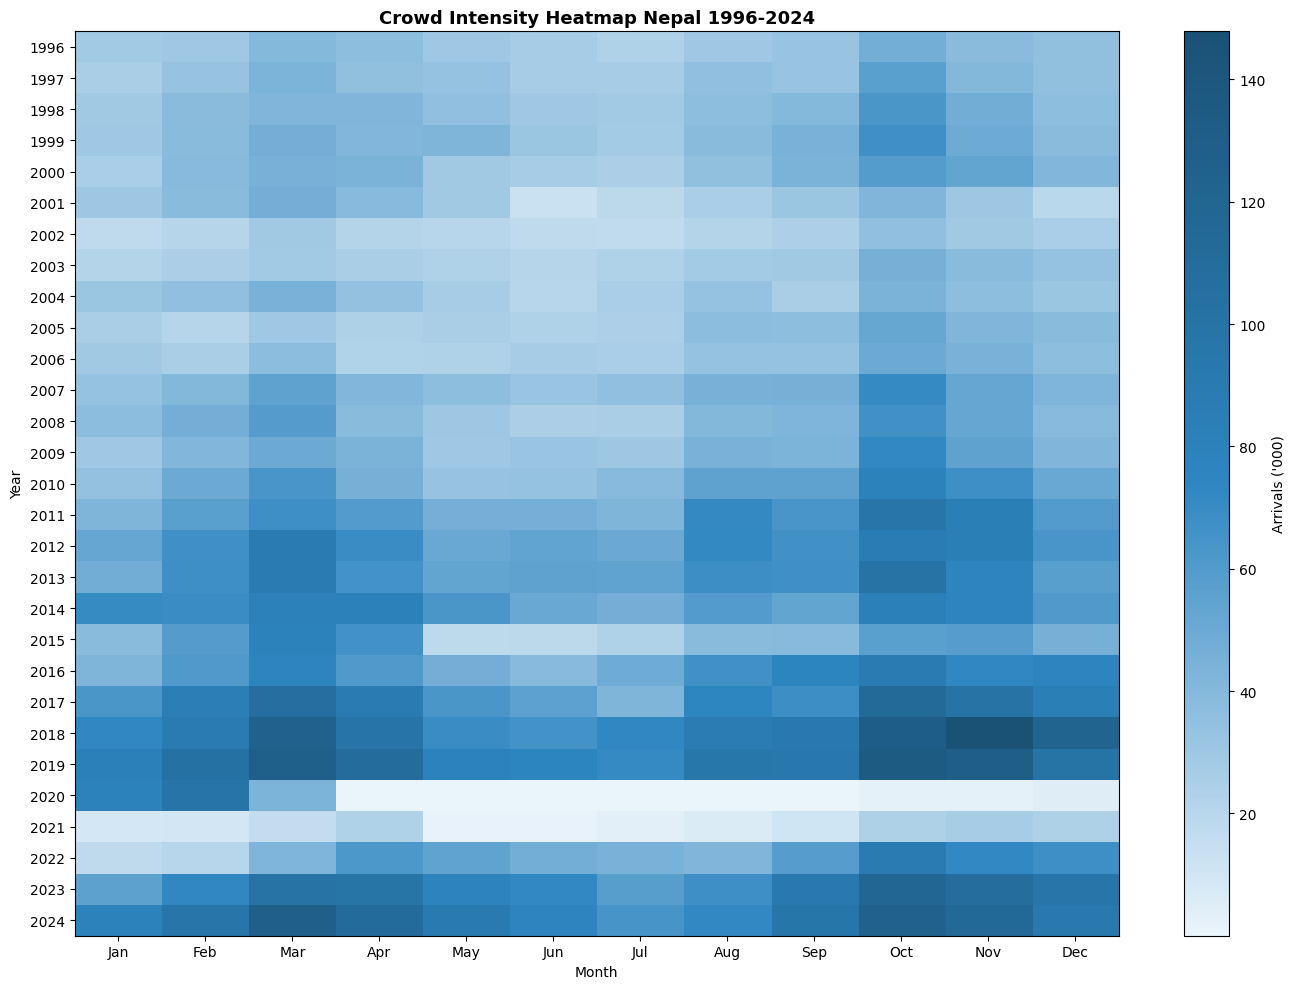

In [45]:
from matplotlib.colors import LinearSegmentedColormap

month_cols = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Prepare the data for the heatmap:
# Set 'Year' as the index of the monthly_df DataFrame.
heatmap_data = monthly_df.set_index('Year')[month_cols]

# Create a figure and an axes object for the plot with a specified size.
fig, ax = plt.subplots(figsize=(14, 10))

# It creates a gradient from light blue to dark blue for 'tourism' intensity.
cmap = LinearSegmentedColormap.from_list(
      'tourism', ['#eaf4fb', '#2e86c1', '#1a5276']
)

# Display the heatmap using imshow.
# `heatmap_data.values/1000` scales the arrival numbers to thousands for better readability.
# `aspect='auto'` adjusts the aspect ratio of the cells automatically.
# `cmap` applies the custom color map.
im = ax.imshow(heatmap_data.values/1000, aspect='auto', cmap=cmap)

# Set x-axis ticks and labels to correspond to the months.
ax.set_xticks(range(12)); ax.set_xticklabels(month_cols)

# Set y-axis ticks and labels to correspond to the years.
ax.set_yticks(range(len(heatmap_data))); ax.set_yticklabels(heatmap_data.index)

# Add a color bar to the right of the heatmap to indicate the scale of arrivals.
plt.colorbar(im, ax=ax, label="Arrivals ('000)")

# Set the title of the heatmap.
ax.set_title('Crowd Intensity Heatmap Nepal 1996-2024', fontsize=13, fontweight='bold')

# Set the x and y axis labels.
ax.set_xlabel('Month'); ax.set_ylabel('Year')
plt.tight_layout()
plt.savefig('eda1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**ANNUAL TREND**

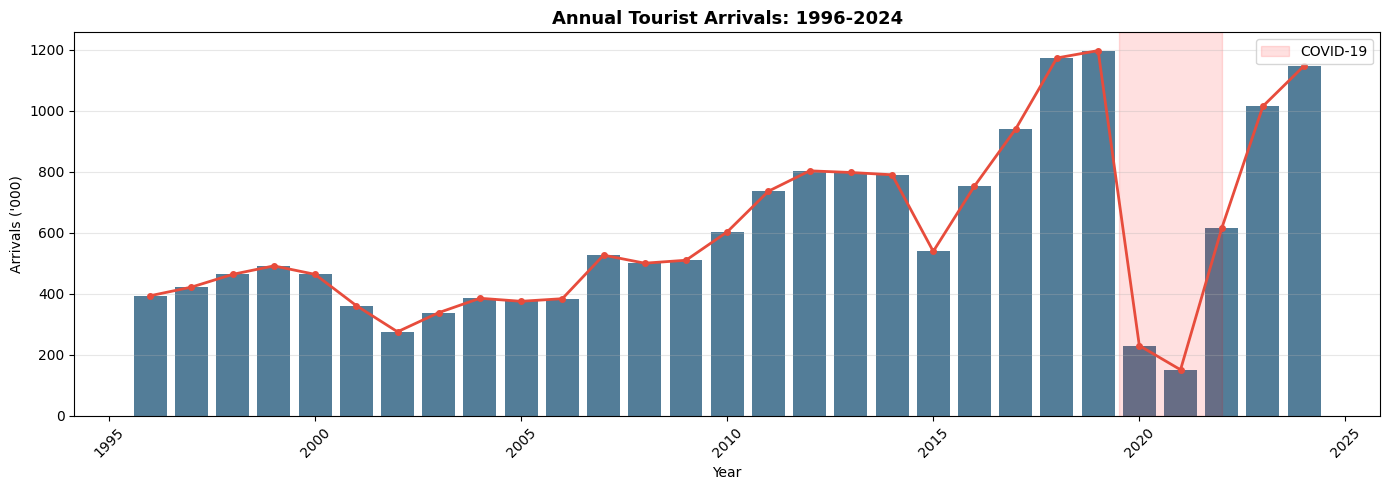

In [46]:
import matplotlib.pyplot as plt
import pandas as pd

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(annual_df['Year'], annual_df['Total']/1000, color='#1a5276', alpha=0.75)

ax.plot(annual_df['Year'], annual_df['Total']/1000, color='#e74c3c', linewidth=2, marker='o', markersize=4)

# Add a shaded vertical span to highlight the COVID-19 period (2019.5 to 2022).
# This provides a visual cue for the impact of the pandemic.
ax.axvspan(2019.5, 2022, alpha=0.12, color='red', label='COVID-19')

# Set the title of the plot
ax.set_title('Annual Tourist Arrivals: 1996-2024', fontsize=13, fontweight='bold')

# Set the x-axis label ('Year') and y-axis label ('Arrivals ('000)').
ax.set_xlabel('Year'); ax.set_ylabel("Arrivals ('000)")

# Display the legend and add a horizontal grid for better readability.
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('eda2_annual_trend.png', dpi=150, bbox_inches='tight')
plt.show()

**PURPOSE OF VISIT**

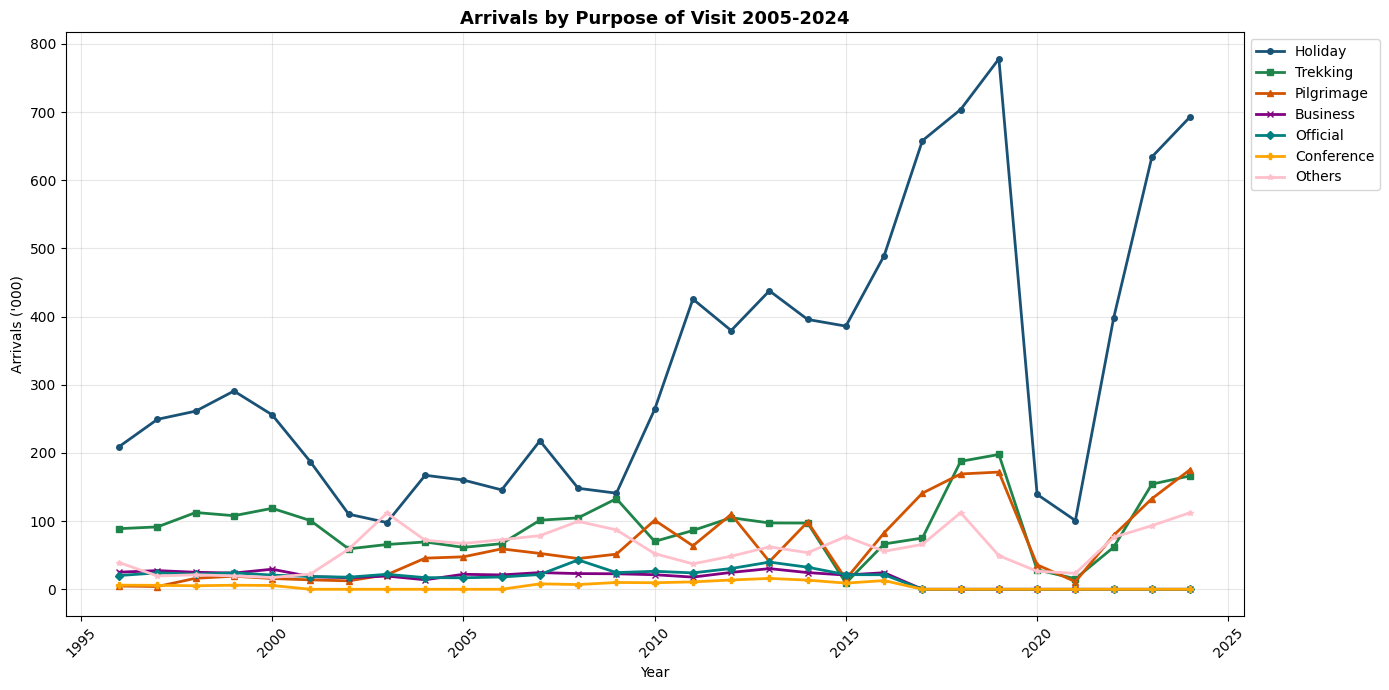

In [47]:
df_p = purpose_df[purpose_df['Year'] >= 1996]

fig, ax = plt.subplots(figsize=(14, 7)) # Increased figure height for more lines
ax.plot(df_p['Year'], df_p['Holiday']/1000, color='#1a5276', marker='o', markersize=4, linewidth=2, label='Holiday')
ax.plot(df_p['Year'], df_p['Trekking']/1000, color='#1e8449', marker='s', markersize=4, linewidth=2, label='Trekking')
ax.plot(df_p['Year'], df_p['Pilgrimage']/1000, color='#d35400', marker='^', markersize=4, linewidth=2, label='Pilgrimage')
ax.plot(df_p['Year'], df_p['Business']/1000, color='#800080', marker='x', markersize=4, linewidth=2, label='Business') # Added Business
ax.plot(df_p['Year'], df_p['Official']/1000, color='#008080', marker='D', markersize=4, linewidth=2, label='Official')   # Added Official
ax.plot(df_p['Year'], df_p['Conference']/1000, color='#FFA500', marker='P', markersize=4, linewidth=2, label='Conference') # Added Conference
ax.plot(df_p['Year'], df_p['Others']/1000, color='#FFC0CB', marker='*', markersize=4, linewidth=2, label='Others')       # Added Others
ax.set_title('Arrivals by Purpose of Visit 2005-2024', fontsize=13, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel("Arrivals ('000)")
ax.legend(loc='upper left', bbox_to_anchor=(1,1)); ax.grid(True, alpha=0.3) # Adjusted legend position
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('eda3_purpose.png', dpi=150, bbox_inches='tight')
plt.show()

**LENGTH OF STAY**

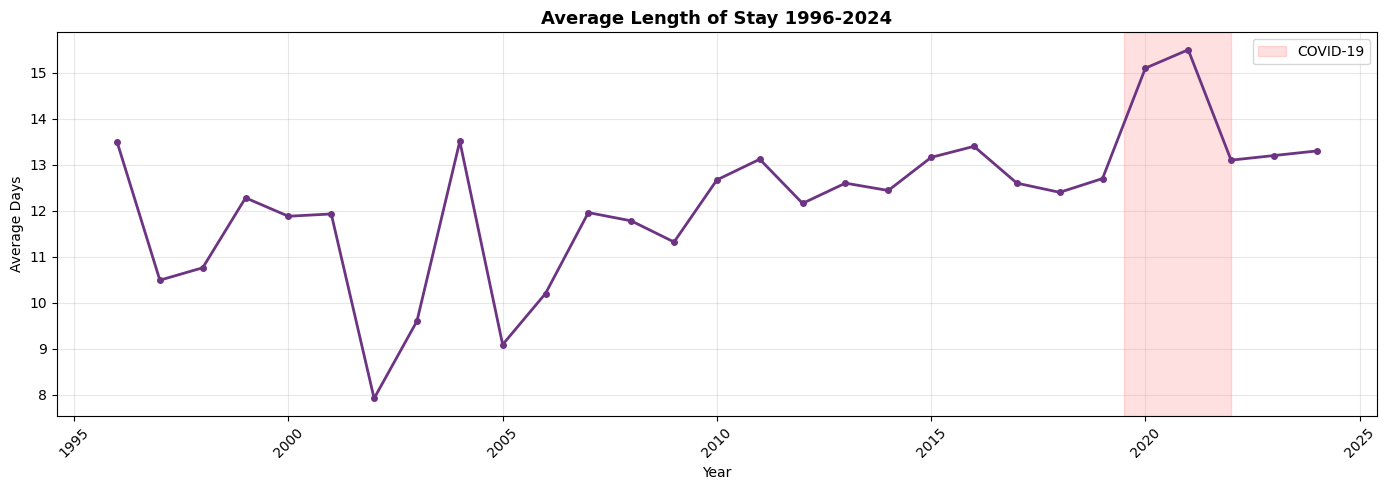

In [48]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(stay_df['Year'], stay_df['Avg_Stay_Days'], color='#6c3483', linewidth=2, marker='o', markersize=4)
ax.axvspan(2019.5, 2022, alpha=0.12, color='red', label='COVID-19')
ax.set_title('Average Length of Stay 1996-2024', fontsize=13, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Average Days')
ax.legend(); ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('eda4_length_of_stay.png', dpi=150, bbox_inches='tight')
plt.show()

**AIC TEST**

In [49]:
import itertools
from statsmodels.tsa.arima.model import ARIMA # Added this import

# AIC OPTIMIZATION
# We test many combinations of p, q, P, Q
# The combination with lowest AIC is the best
# We run this on TRAINING data only (1995-2022)
# Training data for AIC search

train_aic       = series['1996-01':'2022-12']
train_dummy_aic = ts_df['covid_dummy']['1996-01':'2022-12']

d = 1
D = 1
s = 12

p_values = [0, 1, 2]
q_values = [0, 1, 2]
P_values = [0, 1]
Q_values = [0, 1]

# ARIMA AIC SEARCH
print(" ARIMA AIC SEARCH ")
print("Testing p and q combinations (d=1 fixed)")
print("Please wait...\n")

arima_results = []

for p, q in itertools.product(p_values, q_values):
    try:
        model = ARIMA(train_aic, order=(p, d, q))
        fitted = model.fit()
        arima_results.append({
            'p': p, 'd': d, 'q': q,
            'AIC': fitted.aic
        })
        print(f"  ARIMA({p},{d},{q})  AIC = {fitted.aic:.2f}")
    except Exception as e:
        # Print the actual exception for better debugging
        print(f"  ARIMA({p},{d},{q})  Failed with error: {e} - skipping")

arima_results_df = pd.DataFrame(arima_results)

# Check if arima_results_df is empty before attempting to sort
if not arima_results_df.empty:
    arima_results_df = arima_results_df.sort_values('AIC').reset_index(drop=True)

    print("\n TOP 5 ARIMA MODELS ")
    print(arima_results_df.head(5).to_string())

    best_p = int(arima_results_df.iloc[0]['p'])
    best_q = int(arima_results_df.iloc[0]['q'])
    print(f"\n Best ARIMA : ({best_p}, {d}, {best_q})")
else:
    print("\nNo ARIMA models could be fitted. `arima_results_df` is empty.")
    # Assign default values or handle this case appropriately if further code depends on best_p/best_q
    best_p = 1 # Fallback to a common default
    best_q = 1 # Fallback to a common default
    print(f"\nDefaulting to ARIMA parameters: ({best_p}, {d}, {best_q})")


 ARIMA AIC SEARCH 
Testing p and q combinations (d=1 fixed)
Please wait...

  ARIMA(0,1,0)  AIC = 7096.26
  ARIMA(0,1,1)  AIC = 7097.10


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

  ARIMA(0,1,2)  AIC = 7074.29
  ARIMA(1,1,0)  AIC = 7097.55


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

  ARIMA(1,1,1)  AIC = 7072.10
  ARIMA(1,1,2)  AIC = 7066.78


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

  ARIMA(2,1,0)  AIC = 7090.06
  ARIMA(2,1,1)  AIC = 7061.49


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

  ARIMA(2,1,2)  AIC = 7023.07

 TOP 5 ARIMA MODELS 
   p  d  q          AIC
0  2  1  2  7023.065972
1  2  1  1  7061.487843
2  1  1  2  7066.784773
3  1  1  1  7072.098739
4  0  1  2  7074.293550

→ Best ARIMA : (2, 1, 2)


In [50]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

#  SARIMAX AIC SEARCH
print(" SARIMAX AIC SEARCH ")
print("Testing P and Q combinations (p,d,q,D,s fixed)")
print("Please wait...\n")

sarimax_results = []

for p, q, P, Q in itertools.product(
    p_values, q_values, P_values, Q_values
):
    try:
        model = SARIMAX(
            train_aic,
            exog=train_dummy_aic,
            order=(p, d, q),
            seasonal_order=(P, D, Q, s),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        fitted = model.fit(disp=False)
        sarimax_results.append({
            'p': p, 'd': d, 'q': q,
            'P': P, 'D': D, 'Q': Q,
            'AIC': fitted.aic
        })
        print(f"  SARIMAX({p},{d},{q})({P},{D},{Q},12)"
              f"  AIC = {fitted.aic:.2f}")
    except Exception as e:
        print(f"  SARIMAX({p},{d},{q})({P},{D},{Q},12)"
              f"  Failed with error: {e} — skipping")

sarimax_results_df = pd.DataFrame(sarimax_results)

# Check if sarimax_results_df is empty before attempting to sort
if not sarimax_results_df.empty:
    sarimax_results_df = sarimax_results_df.sort_values(
        'AIC'
    ).reset_index(drop=True)

    print("\n TOP 5 SARIMAX MODELS ")
    print(sarimax_results_df.head(5).to_string())

    best_p_sx = int(sarimax_results_df.iloc[0]['p'])
    best_q_sx = int(sarimax_results_df.iloc[0]['q'])
    best_P    = int(sarimax_results_df.iloc[0]['P'])
    best_Q    = int(sarimax_results_df.iloc[0]['Q'])
    print(f"\n→ Best SARIMAX : ({best_p_sx},{d},{best_q_sx})"
          f"({best_P},{D},{best_Q},{s})")
else:
    print("\nNo SARIMAX models could be fitted. `sarimax_results_df` is empty.")
    # Assign fallback values if no models were fitted to prevent further errors
    best_p_sx = 1 # Fallback default
    best_q_sx = 1 # Fallback default
    best_P    = 1 # Fallback default
    best_Q    = 1 # Fallback default
    print(f"\nDefaulting to SARIMAX parameters: ({best_p_sx},{d},{best_q_sx})({best_P},{D},{best_Q},{s})")

 SARIMAX AIC SEARCH 
Testing P and Q combinations (p,d,q,D,s fixed)
Please wait...

  SARIMAX(0,1,0)(0,1,0,12)  AIC = 8217.80


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


  SARIMAX(0,1,0)(0,1,1,12)  AIC = 6373.02
  SARIMAX(0,1,0)(1,1,0,12)  AIC = 6438.30


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


  SARIMAX(0,1,0)(1,1,1,12)  AIC = 6372.64
  SARIMAX(0,1,1)(0,1,0,12)  AIC = 6684.31


...

  SARIMAX(2,1,2)(0,1,1,12)  AIC = 6318.63


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


  SARIMAX(2,1,2)(1,1,0,12)  AIC = 6373.36


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


  SARIMAX(2,1,2)(1,1,1,12)  AIC = 6320.59

 TOP 5 SARIMAX MODELS 
   p  d  q  P  D  Q          AIC
0  1  1  2  0  1  1  6317.995981
1  2  1  2  0  1  1  6318.631007
2  0  1  2  0  1  1  6319.285417
3  1  1  2  1  1  1  6319.903925
4  1  1  1  0  1  1  6320.155530

→ Best SARIMAX : (1,1,2)(0,1,1,12)


In [51]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
import pandas as pd
import itertools

print(" SARIMAX AIC SEARCH ")
print("Testing parameter combinations...")
print()

sarimax_results = []

for p, q, P, Q in itertools.product(
        p_values, q_values, P_values, Q_values):

    try:

        model = SARIMAX(
            train_aic,
            exog=train_dummy_aic,
            order=(p, d, q),
            seasonal_order=(P, D, Q, s),
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted = model.fit(disp=False)

        # Ljung-Box test
        lb_p = acorr_ljungbox(
            fitted.resid.dropna(),
            lags=[12],
            return_df=True
        )['lb_pvalue'].iloc[0]

        sarimax_results.append({
            'p': p,
            'd': d,
            'q': q,
            'P': P,
            'D': D,
            'Q': Q,
            'AIC': fitted.aic,
            'BIC': fitted.bic,
            'LjungBox_p': lb_p
        })

        print(
            f"SARIMAX({p},{d},{q})({P},{D},{Q},{s}) "
            f"AIC={fitted.aic:.2f} "
            f"BIC={fitted.bic:.2f} "
            f"LB-p={lb_p:.4f}"
        )

    except Exception:
        continue

# RESULTS

sarimax_results_df = pd.DataFrame(sarimax_results)

if not sarimax_results_df.empty:

    # Sort by AIC
    sarimax_results_df = (
        sarimax_results_df
        .sort_values('AIC')
        .reset_index(drop=True)
    )

    print("\n TOP 10 SARIMAX MODELS ")
    print(sarimax_results_df.head(10))

    # Best model
    best_model = sarimax_results_df.iloc[0]

    best_p_sx = int(best_model['p'])
    best_q_sx = int(best_model['q'])
    best_P    = int(best_model['P'])
    best_Q    = int(best_model['Q'])

    print(
        f"\nBest SARIMAX by AIC:"
        f"\n({best_p_sx},{d},{best_q_sx})"
        f"({best_P},{D},{best_Q},{s})"
    )

    print(
        f"\nAIC = {best_model['AIC']:.2f}"
        f"\nBIC = {best_model['BIC']:.2f}"
        f"\nLjung-Box p = {best_model['LjungBox_p']:.4f}"
    )

    # Models with white-noise residuals
    good_models = sarimax_results_df[
        sarimax_results_df['LjungBox_p'] > 0.05
    ]

    if not good_models.empty:
        print("\n MODELS WITH Ljung-Box p > 0.05 ")
        print(good_models.head(10))

else:
    print("No SARIMAX models could be fitted.")

 SARIMAX AIC SEARCH 
Testing parameter combinations...

SARIMAX(0,1,0)(0,1,0,12) AIC=8217.80 BIC=8225.27 LB-p=0.0000


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


SARIMAX(0,1,0)(0,1,1,12) AIC=6373.02 BIC=6384.11 LB-p=0.0000
SARIMAX(0,1,0)(1,1,0,12) AIC=6438.30 BIC=6449.40 LB-p=0.0000


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


SARIMAX(0,1,0)(1,1,1,12) AIC=6372.64 BIC=6387.42 LB-p=0.0000
SARIMAX(0,1,1)(0,1,0,12) AIC=6684.31 BIC=6695.51 LB-p=0.0000


...

SARIMAX(2,1,2)(0,1,1,12) AIC=6318.63 BIC=6344.46 LB-p=0.0394


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


SARIMAX(2,1,2)(1,1,0,12) AIC=6373.36 BIC=6399.22 LB-p=0.1019


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


SARIMAX(2,1,2)(1,1,1,12) AIC=6320.59 BIC=6350.11 LB-p=0.0435

 TOP 10 SARIMAX MODELS 
   p  d  q  P  D  Q          AIC          BIC  LjungBox_p
0  1  1  2  0  1  1  6317.995981  6340.138137    0.009183
1  2  1  2  0  1  1  6318.631007  6344.463523    0.039416
2  0  1  2  0  1  1  6319.285417  6337.737215    0.017816
3  1  1  2  1  1  1  6319.903925  6345.736441    0.011897
4  1  1  1  0  1  1  6320.155530  6338.624190    0.012427
5  2  1  2  1  1  1  6320.590404  6350.113280    0.043500
6  0  1  2  1  1  1  6321.280522  6343.422678    0.018386
7  0  1  1  0  1  1  6324.448292  6339.223220    0.000075
8  2  1  1  0  1  1  6338.479666  6360.642059    0.019857
9  2  1  1  1  1  1  6340.479332  6366.335457    0.019966

Best SARIMAX by AIC:
(1,1,2)(0,1,1,12)

AIC = 6318.00
BIC = 6340.14
Ljung-Box p = 0.0092

 MODELS WITH Ljung-Box p > 0.05 
    p  d  q  P  D  Q          AIC          BIC  LjungBox_p
18  2  1  2  1  1  0  6373.362577  6399.218702    0.101862
21  1  1  2  1  1  0  6393.723656 

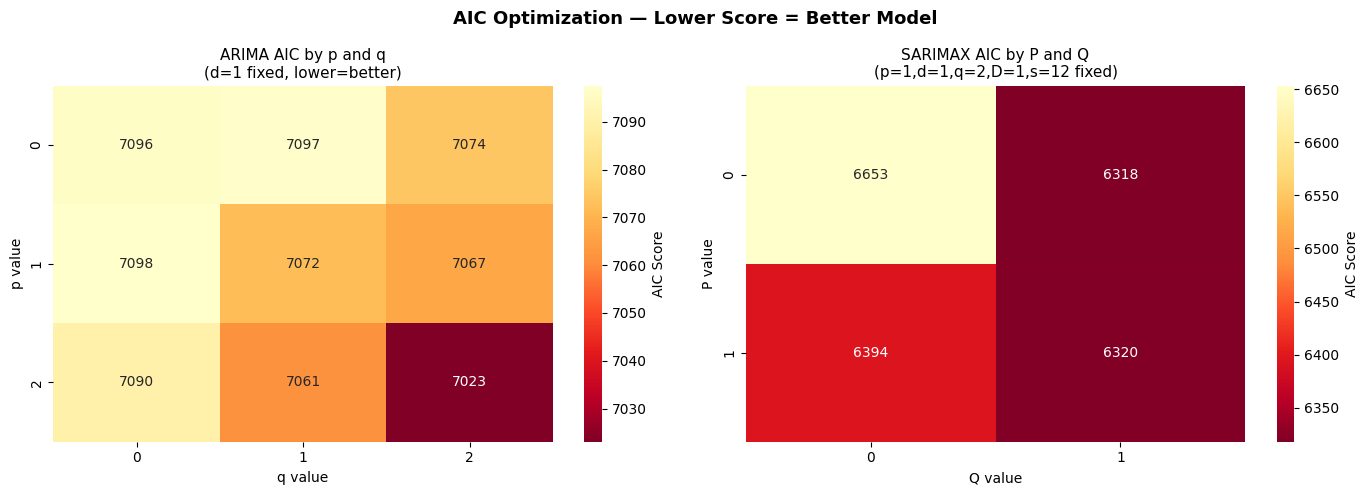

Graph saved

Best ARIMA   : (2,1,2)
Best SARIMAX : (1,1,2)(0,1,1,12)


In [52]:
# AIC comparison graph
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('AIC Optimization — Lower Score = Better Model',
             fontsize=13, fontweight='bold')

# ARIMA heatmap
arima_pivot = arima_results_df.pivot_table(
    values='AIC', index='p', columns='q'
)
sns.heatmap(arima_pivot, annot=True, fmt='.0f',
            cmap='YlOrRd_r', ax=axes[0],
            cbar_kws={'label': 'AIC Score'})
axes[0].set_title('ARIMA AIC by p and q\n(d=1 fixed, lower=better)',
                  fontsize=11)
axes[0].set_xlabel('q value')
axes[0].set_ylabel('p value')

# SARIMAX heatmap (best p,q combination)
sarimax_best_pq = sarimax_results_df[
    (sarimax_results_df['p'] == best_p_sx) &
    (sarimax_results_df['q'] == best_q_sx)
]
sarimax_pivot = sarimax_best_pq.pivot_table(
    values='AIC', index='P', columns='Q'
)
sns.heatmap(sarimax_pivot, annot=True, fmt='.0f',
            cmap='YlOrRd_r', ax=axes[1],
            cbar_kws={'label': 'AIC Score'})
axes[1].set_title(
    f'SARIMAX AIC by P and Q\n'
    f'(p={best_p_sx},d=1,q={best_q_sx},D=1,s=12 fixed)',
    fontsize=11
)
axes[1].set_xlabel('Q value')
axes[1].set_ylabel('P value')

plt.tight_layout()
plt.savefig('aic_optimization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph saved")
print(f"\nBest ARIMA   : ({best_p},{d},{best_q})")
print(f"Best SARIMAX : ({best_p_sx},{d},{best_q_sx})"
      f"({best_P},{D},{best_Q},{s})")

In [53]:

# TRAIN / TEST SPLIT
#
# Training : January 1995 to December 2022
# includes COVID period
# COVID dummy handles the disruption
# model learns from full history
#
# Test     : January 2023 to December 2024
# clean post-COVID recovery data
# no near-zero months

train = series['1996-01':'2022-12']
test  = series['2023-01':'2024-12']

train_dummy = ts_df['covid_dummy']['1996-01':'2022-12']
test_dummy  = ts_df['covid_dummy']['2023-01':'2024-12']

print(" TRAIN / TEST SPLIT ")
print(f"Training : {train.index[0].strftime('%B %Y')} "
      f"to {train.index[-1].strftime('%B %Y')} "
      f"— {len(train)} months")
print(f"Test     : {test.index[0].strftime('%B %Y')} "
      f"to {test.index[-1].strftime('%B %Y')} "
      f"— {len(test)} months")
print(f"\nTraining COVID months (dummy=1) : "
      f"{train_dummy.sum()}")
print(f"Test COVID months (dummy=1)     : "
      f"{test_dummy.sum()} (should be 0)")
print(f"\nTest arrivals range : "
      f"{test.min():,.0f} to {test.max():,.0f}")
print("No near-zero COVID values in test")

 TRAIN / TEST SPLIT 
Training : January 1996 to December 2022 — 324 months
Test     : January 2023 to December 2024 — 24 months

Training COVID months (dummy=1) : 21
Test COVID months (dummy=1)     : 0 (should be 0)

Test arrivals range : 55,074 to 128,167
No near-zero COVID values in test


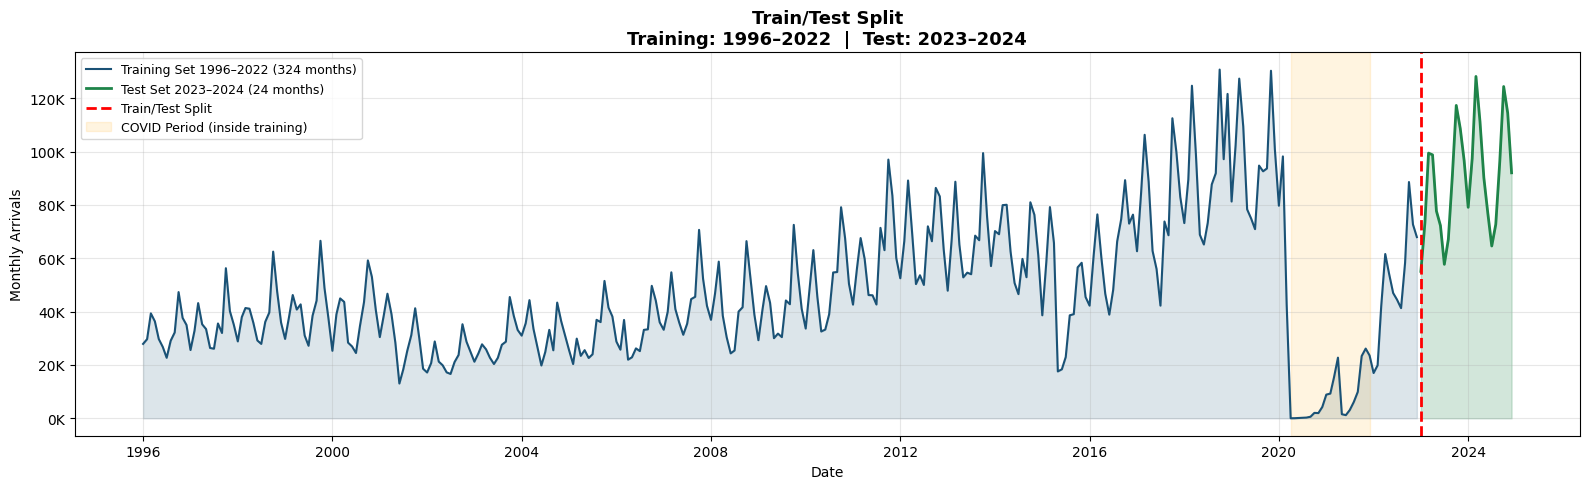

Graph saved


In [54]:
# Train/test split graph
fig, ax = plt.subplots(figsize=(16, 5))

ax.fill_between(train.index, train.values,
                alpha=0.15, color='#1a5276')
ax.fill_between(test.index, test.values,
                alpha=0.2, color='#1e8449')

ax.plot(train.index, train.values,
        color='#1a5276', linewidth=1.5,
        label=f'Training Set 1996–2022 ({len(train)} months)')
ax.plot(test.index, test.values,
        color='#1e8449', linewidth=2,
        label=f'Test Set 2023–2024 ({len(test)} months)')

# Split point line
ax.axvline(pd.Timestamp('2023-01-01'),
           color='red', linestyle='--',
           linewidth=2, label='Train/Test Split')

# COVID shading inside training
ax.axvspan(pd.Timestamp('2020-04-01'),
           pd.Timestamp('2021-12-01'),
           alpha=0.12, color='orange',
           label='COVID Period (inside training)')

ax.set_title(
    'Train/Test Split\n'
    'Training: 1996–2022  |  Test: 2023–2024',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Date')
ax.set_ylabel('Monthly Arrivals')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K')
)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph saved")


**ARIMA MODEL**

In [55]:

# ARIMA MODEL
# Baseline model - trend only, no seasonality
# Parameters from AIC optimization

print(f" FITTING ARIMA({best_p},{d},{best_q}) ")
print(f"Training: 1996-01 to 2022-12\n")

arima_model = ARIMA(train, order=(best_p, d, best_q))
arima_fit   = arima_model.fit()

print(arima_fit.summary())

 FITTING ARIMA(2,1,2) 
Training: 1996-01 to 2022-12



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:      Arrivals_Smoothed   No. Observations:                  324
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -3506.533
Date:                Tue, 28 Jul 2026   AIC                           7023.066
Time:                        13:55:38   BIC                           7041.954
Sample:                    01-01-1996   HQIC                          7030.606
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0008      0.010     95.450      0.000       0.980       1.021
ar.L2         -0.9875      0.011    -92.771      0.000      -1.008      -0.967
ma.L1         -1.0413      0.029    -35.430      0.0

In [56]:

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.stats.diagnostic import acorr_ljungbox

# Forecast on test period 2023-2024
arima_forecast = arima_fit.forecast(steps=len(test))
arima_forecast.index = test.index

# Calculate error metrics
# All test months are normal post-COVID, no near-zero values
arima_mae  = mean_absolute_error(test, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))
arima_mape = np.mean(
    np.abs((test - arima_forecast) / test)
) * 100

# Ljung-Box residual test
lb_arima   = acorr_ljungbox(
    arima_fit.resid, lags=[12], return_df=True
)
lb_p_arima = lb_arima['lb_pvalue'].values[0]

print(f"\n=== ARIMA({best_p},{d},{best_q}) — EVALUATION ===")
print(f"Test period : Jan 2023 to Dec 2024")
print(f"MAE         : {arima_mae:,.0f}")
print(f"RMSE        : {arima_rmse:,.0f}")
print(f"MAPE        : {arima_mape:.2f}%")
print(f"Ljung-Box p : {lb_p_arima:.4f}")
print(f"Residuals   : "
      f"{'Random — model valid' if lb_p_arima > 0.05 else 'Autocorrelated — pattern left'}")



=== ARIMA(2,1,2) — EVALUATION ===
Test period : Jan 2023 to Dec 2024
MAE         : 18,719
RMSE        : 23,537
MAPE        : 18.56%
Ljung-Box p : 0.0000
Residuals   : Autocorrelated — pattern left


**SARIMA MODEL**

In [57]:

# SARIMAX MODEL
# Handles seasonality (s=12) + COVID dummy
# Parameters from AIC optimization

print(f"FITTING SARIMAX({best_p_sx},{d},{best_q_sx})"
      f"({best_P},{D},{best_Q},{s})")
print(f"Training: 1996-01 to 2022-12\n")

sarimax_model = SARIMAX(
    train,
    exog=train_dummy,
    order=(best_p_sx, d, best_q_sx),
    seasonal_order=(best_P, D, best_Q, s),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_fit = sarimax_model.fit(disp=False)

print(sarimax_fit.summary())

=== FITTING SARIMAX(1,1,2)(0,1,1,12) ===
Training: 1996-01 to 2022-12



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                       
Dep. Variable:                    Arrivals_Smoothed   No. Observations:                  324
Model:             SARIMAX(1, 1, 2)x(0, 1, [1], 12)   Log Likelihood               -3152.998
Date:                              Tue, 28 Jul 2026   AIC                           6317.996
Time:                                      13:55:39   BIC                           6340.138
Sample:                                  01-01-1996   HQIC                          6326.861
                                       - 12-01-2022                                         
Covariance Type:                                opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
covid_dummy -2.128e+04   5712.523     -3.725      0.000   -3.25e+04   -1.01e+04
ar.L1          -

In [58]:
# Forecast on test period 2023-2024
# Test dummy = all zeros because 2023-2024 has no COVID
sarimax_forecast = sarimax_fit.forecast(
    steps=len(test), exog=test_dummy
)
sarimax_forecast.index = test.index

# Calculate error metrics
sarimax_mae  = mean_absolute_error(test, sarimax_forecast)
sarimax_rmse = np.sqrt(mean_squared_error(test, sarimax_forecast))
sarimax_mape = np.mean(
    np.abs((test - sarimax_forecast) / test)
) * 100

lb_sarimax   = acorr_ljungbox(
    sarimax_fit.resid, lags=[12], return_df=True
)
lb_p_sarimax = lb_sarimax['lb_pvalue'].values[0]

print(f"\n SARIMAX({best_p_sx},{d},{best_q_sx})"
      f"({best_P},{D},{best_Q},{s}) - EVALUATION ")
print(f"Test period : Jan 2023 to Dec 2024")
print(f"MAE         : {sarimax_mae:,.0f}")
print(f"RMSE        : {sarimax_rmse:,.0f}")
print(f"MAPE        : {sarimax_mape:.2f}%")
print(f"Ljung-Box p : {lb_p_sarimax:.4f}")
print(f"Residuals   : "
      f"{'Random - model valid' if lb_p_sarimax > 0.05 else 'Autocorrelated'}")


=== SARIMAX(1,1,2)(0,1,1,12) — EVALUATION ===
Test period : Jan 2023 to Dec 2024
MAE         : 27,012
RMSE        : 29,545
MAPE        : 28.62%
Ljung-Box p : 0.0092
Residuals   : Autocorrelated


In [59]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np
import itertools
import warnings

warnings.filterwarnings("ignore")

# TRAIN / TEST

train = series[:'2022-12']
test  = series['2023-01':'2024-12']

train_exog = ts_df[['covid_dummy']][:'2022-12']
test_exog  = ts_df[['covid_dummy']]['2023-01':'2024-12']

# EXPANDED SARIMAX SEARCH

results = []

p_values = [0,1,2,3]
q_values = [0,1,2,3]

P_values = [0,1,2]
Q_values = [0,1,2]

d = 1
D = 1
s = 12

for p, q, P, Q in itertools.product(
        p_values,
        q_values,
        P_values,
        Q_values):

    try:

        model = SARIMAX(
            train,
            exog=train_exog,
            order=(p,d,q),
            seasonal_order=(P,D,Q,s),
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fit = model.fit(disp=False)

        forecast = fit.forecast(
            steps=len(test),
            exog=test_exog
        )

        mae = mean_absolute_error(test, forecast)

        rmse = np.sqrt(
            mean_squared_error(test, forecast)
        )

        mape = (
            np.mean(
                np.abs(
                    (test - forecast) / test
                )
            ) * 100
        )

        lb_p = acorr_ljungbox(
            fit.resid.dropna(),
            lags=[12],
            return_df=True
        )['lb_pvalue'].iloc[0]

        results.append({
            'Order': f'({p},{d},{q})',
            'Seasonal': f'({P},{D},{Q},{s})',
            'MAE': mae,
            'RMSE': rmse,
            'MAPE': mape,
            'AIC': fit.aic,
            'LB_p': lb_p
        })

        print(
            f"Done ({p},{d},{q}) "
            f"({P},{D},{Q},{s}) "
            f"MAPE={mape:.2f}% "
            f"LB={lb_p:.4f}"
        )

    except:
        continue

# RESULTS
results_df = pd.DataFrame(results)

# Sort by forecast accuracy first
results_df = results_df.sort_values(
    ['MAPE', 'RMSE']
).reset_index(drop=True)

print("\n=== TOP 20 MODELS ===")
print(results_df.head(20))

# Models with white-noise residuals
good_models = results_df[
    results_df['LB_p'] > 0.05
]

print("\n=== MODELS WITH LB p > 0.05 ===")
print(good_models.head(20))

results_df.to_csv(
    'sarimax_parameter_search.csv',
    index=False
)

print("\nSaved: sarimax_parameter_search.csv")

Done (0,1,0) (0,1,0,12) MAPE=16.65% LB=0.0000
Done (0,1,0) (0,1,1,12) MAPE=30.37% LB=0.0000
Done (0,1,0) (0,1,2,12) MAPE=31.72% LB=0.0000
Done (0,1,0) (1,1,0,12) MAPE=13.70% LB=0.0000
Done (0,1,0) (1,1,1,12) MAPE=31.56% LB=0.0000
Done (0,1,0) (1,1,2,12) MAPE=29.88% LB=0.0000
Done (0,1,0) (2,1,0,12) MAPE=38.70% LB=0.0000
Done (0,1,0) (2,1,1,12) MAPE=33.51% LB=0.0000
Done (0,1,0) (2,1,2,12) MAPE=29.14% LB=0.0000
Done (0,1,1) (0,1,0,12) MAPE=16.93% LB=0.0000
Done (0,1,1) (0,1,1,12) MAPE=29.36% LB=0.0001
Done (0,1,1) (0,1,2,12) MAPE=28.88% LB=0.0000
Done (0,1,1) (1,1,0,12) MAPE=13.95% LB=0.0026
Done (0,1,1) (1,1,1,12) MAPE=28.86% LB=0.0001
Done (0,1,1) (1,1,2,12) MAPE=29.56% LB=0.0000
Done (0,1,1) (2,1,0,12) MAPE=41.93% LB=0.0006
Done (0,1,1) (2,1,1,12) MAPE=32.73% LB=0.0000
Done (0,1,1) (2,1,2,12) MAPE=29.19% LB=0.0000
Done (0,1,2) (0,1,0,12) MAPE=17.03% LB=0.0000
Done (0,1,2) (0,1,1,12) MAPE=29.16% LB=0.0178
Done (0,1,2) (0,1,2,12) MAPE=29.10% LB=0.0146
Done (0,1,2) (1,1,0,12) MAPE=13.93

In [60]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


# SELECTED BEST MODEL

best_p_sx = 3
best_q_sx = 3

best_P = 1
best_Q = 0

d = 1
D = 1
s = 12

# FIT SARIMAX

print(
    f"FITTING SARIMAX({best_p_sx},{d},{best_q_sx})"
    f"({best_P},{D},{best_Q},{s})"
)
print("Training: 1996-01 to 2022-12\n")

sarimax_model = SARIMAX(
    train,
    exog=train_dummy,
    order=(best_p_sx, d, best_q_sx),
    seasonal_order=(best_P, D, best_Q, s),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_model.fit(disp=False)

print(sarimax_fit.summary())

# FORECAST ON TEST SET (2023–2024)

sarimax_forecast = sarimax_fit.forecast(
    steps=len(test),
    exog=test_dummy
)

sarimax_forecast.index = test.index

# EVALUATION METRICS

sarimax_mae = mean_absolute_error(
    test,
    sarimax_forecast
)

sarimax_rmse = np.sqrt(
    mean_squared_error(
        test,
        sarimax_forecast
    )
)

sarimax_mape = np.mean(
    np.abs(
        (test - sarimax_forecast) / test
    )
) * 100

# LJUNG-BOX TEST

lb_sarimax = acorr_ljungbox(
    sarimax_fit.resid.dropna(),
    lags=[12],
    return_df=True
)

lb_p_sarimax = lb_sarimax[
    'lb_pvalue'
].iloc[0]

# RESULTS

print(
    f"\n SARIMAX({best_p_sx},{d},{best_q_sx})"
    f"({best_P},{D},{best_Q},{s}) - EVALUATION"
)

print("Test period : Jan 2023 to Dec 2024")
print(f"MAE         : {sarimax_mae:,.0f}")
print(f"RMSE        : {sarimax_rmse:,.0f}")
print(f"MAPE        : {sarimax_mape:.2f}%")
print(f"Ljung-Box p : {lb_p_sarimax:.4f}")

if lb_p_sarimax > 0.05:
    print("Residuals   :  Random - model valid")
else:
    print("Residuals   :  Autocorrelated")

=== FITTING SARIMAX(3,1,3)(1,1,0,12) ===
Training: 1996-01 to 2022-12

                                      SARIMAX Results                                      
Dep. Variable:                   Arrivals_Smoothed   No. Observations:                  324
Model:             SARIMAX(3, 1, 3)x(1, 1, [], 12)   Log Likelihood               -3167.701
Date:                             Tue, 28 Jul 2026   AIC                           6353.402
Time:                                     14:02:36   BIC                           6386.615
Sample:                                 01-01-1996   HQIC                          6366.700
                                      - 12-01-2022                                         
Covariance Type:                               opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
covid_dummy -2.128e+04   4758.578

**Model Comparison**

In [87]:

# MODEL COMPARISON
# Test period: Jan 2023 to Dec 2024
# All months are normal post-COVID arrivals

print("=" * 68)
print("  MODEL COMPARISON  TEST PERIOD: Jan 2023 to Dec 2024")
print("=" * 68)
print(f"{'Model':<38} {'MAE':>8} {'RMSE':>9} "
      f"{'MAPE':>7}  Residuals")
print("-" * 68)
print(f"{'ARIMA(' + str(best_p) + ',1,' + str(best_q) + ')':<38} "
      f"{arima_mae:>8,.0f} "
      f"{arima_rmse:>9,.0f} "
      f"{arima_mape:>6.1f}%  "
      f"{'Random' if lb_p_arima > 0.05 else 'Autocorrelated'}")
print(f"{'SARIMAX(' + str(best_p_sx) + ',1,' + str(best_q_sx) + ')(' + str(best_P) + ',1,' + str(best_Q) + ',12) + COVID':<38} "
      f"{sarimax_mae:>8,.0f} "
      f"{sarimax_rmse:>9,.0f} "
      f"{sarimax_mape:>6.1f}%  "
      f"{'Random' if lb_p_sarimax > 0.05 else 'Autocorrelated'}")
print("=" * 68)
print("\nLower MAE/RMSE/MAPE = more accurate model")
print("Random residuals = model captured all patterns correctly")

  MODEL COMPARISON  TEST PERIOD: Jan 2023 to Dec 2024
Model                                       MAE      RMSE    MAPE  Residuals
--------------------------------------------------------------------
ARIMA(2,1,2)                             18,719    23,537   18.6%  Autocorrelated
SARIMAX(3,1,3)(1,1,0,12) + COVID         12,023    14,886   13.7%  Random

Lower MAE/RMSE/MAPE = more accurate model
Random residuals = model captured all patterns correctly


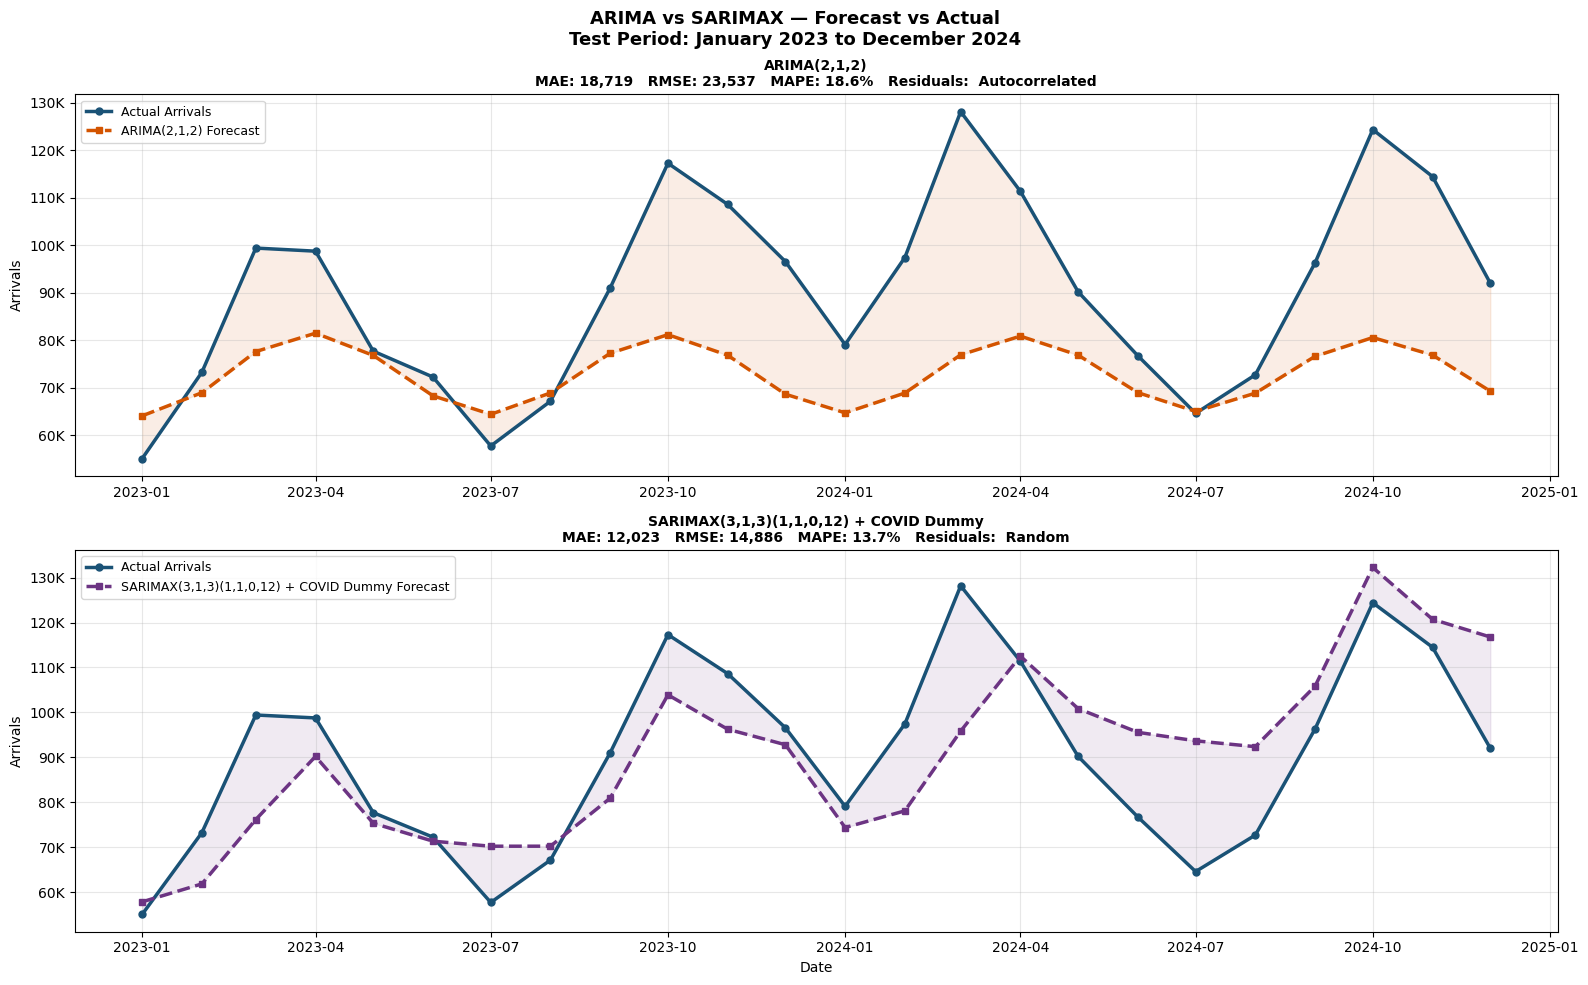

Graph saved


In [62]:
# Comparison graph
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle(
    'ARIMA vs SARIMAX — Forecast vs Actual\n'
    'Test Period: January 2023 to December 2024',
    fontsize=13, fontweight='bold'
)

model_list = [
    (f'ARIMA({best_p},1,{best_q})',
     arima_forecast,
     arima_mae, arima_rmse, arima_mape,
     lb_p_arima, '#d35400'),
    (f'SARIMAX({best_p_sx},1,{best_q_sx})'
     f'({best_P},1,{best_Q},12) + COVID Dummy',
     sarimax_forecast,
     sarimax_mae, sarimax_rmse, sarimax_mape,
     lb_p_sarimax, '#6c3483'),
]

for i, (name, fc, mae, rmse, mape, lb_p, color) in enumerate(model_list):
    axes[i].plot(test.index, test.values,
                 color='#1a5276', linewidth=2.5,
                 marker='o', markersize=5,
                 label='Actual Arrivals')
    axes[i].plot(test.index, fc.values,
                 color=color, linewidth=2.5,
                 linestyle='--', marker='s', markersize=5,
                 label=f'{name} Forecast')
    axes[i].fill_between(test.index,
                         test.values, fc.values,
                         alpha=0.10, color=color)
    axes[i].set_title(
        f'{name}\n'
        f'MAE: {mae:,.0f}   '
        f'RMSE: {rmse:,.0f}   '
        f'MAPE: {mape:.1f}%   '
        f'Residuals: {" Random" if lb_p > 0.05 else " Autocorrelated"}',
        fontsize=10, fontweight='bold'
    )
    axes[i].set_ylabel('Arrivals')
    axes[i].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K')
    )
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

axes[1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph saved")

**RESIDUAL DIAGNOSTICS**

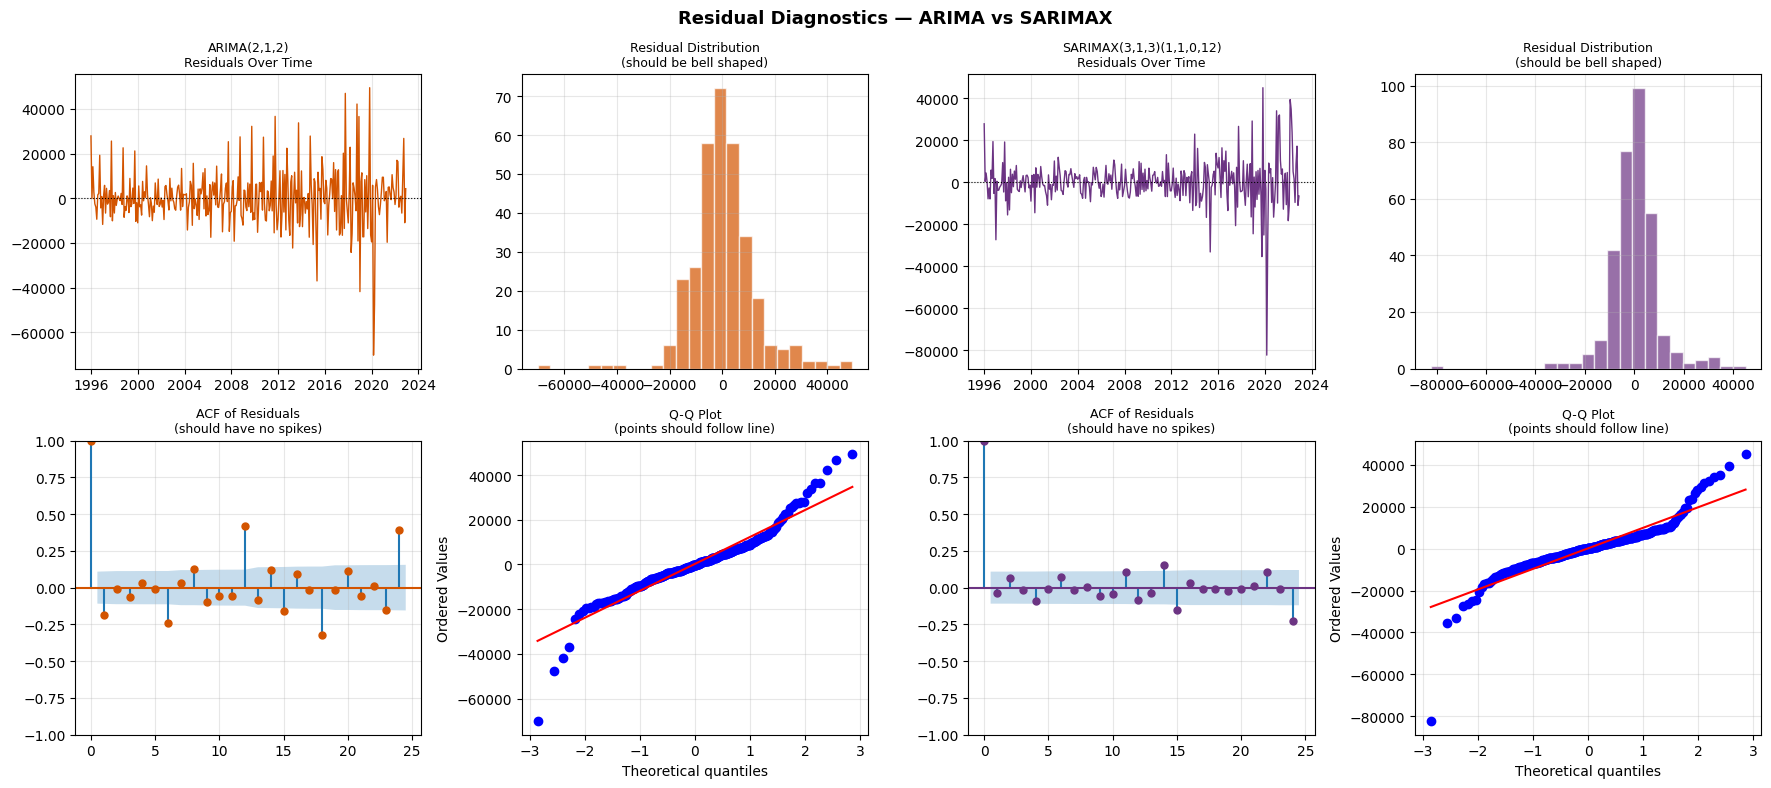

Graph saved


In [63]:
import scipy.stats as scipy_stats

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Residual Diagnostics — ARIMA vs SARIMAX',
             fontsize=13, fontweight='bold')

models_residuals = [
    (f'ARIMA({best_p},1,{best_q})',
     arima_fit, '#d35400'),
    (f'SARIMAX({best_p_sx},1,{best_q_sx})'
     f'({best_P},1,{best_Q},12)',
     sarimax_fit, '#6c3483'),
]

for col, (name, fit, color) in enumerate(models_residuals):
    resid = fit.resid.dropna()

    # Panel 1: Residuals over time
    axes[0, col*2].plot(resid.index, resid.values,
                        color=color, linewidth=1)
    axes[0, col*2].axhline(0, color='black',
                            linewidth=0.8, linestyle=':')
    axes[0, col*2].set_title(f'{name}\nResiduals Over Time',
                              fontsize=9)
    axes[0, col*2].grid(True, alpha=0.3)

    # Panel 2: Histogram
    axes[0, col*2+1].hist(resid.values, bins=25,
                          color=color, alpha=0.7,
                          edgecolor='white')
    axes[0, col*2+1].set_title('Residual Distribution\n'
                                '(should be bell shaped)',
                                fontsize=9)
    axes[0, col*2+1].grid(True, alpha=0.3)

    # Panel 3: ACF of residuals
    plot_acf(resid, lags=24, ax=axes[1, col*2],
             color=color)
    axes[1, col*2].set_title('ACF of Residuals\n'
                              '(should have no spikes)',
                              fontsize=9)
    axes[1, col*2].grid(True, alpha=0.3)

    # Panel 4: Q-Q plot
    scipy_stats.probplot(resid.values, dist='norm',
                         plot=axes[1, col*2+1])
    axes[1, col*2+1].set_title('Q-Q Plot\n'
                                '(points should follow line)',
                                fontsize=9)
    axes[1, col*2+1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph saved")

In [64]:
print("=" * 55)
print("  FINAL MODEL SELECTION")
print("=" * 55)

print(f"\nARIMA({best_p},1,{best_q})")
print(f"  RMSE      : {arima_rmse:,.0f}")
print(f"  MAPE      : {arima_mape:.2f}%")
print(f"  Residuals : {' Random' if lb_p_arima > 0.05 else 'Autocorrelated'}")

print(f"\nSARIMAX({best_p_sx},1,{best_q_sx})"
      f"({best_P},1,{best_Q},12) + COVID Dummy")
print(f"  RMSE      : {sarimax_rmse:,.0f}")
print(f"  MAPE      : {sarimax_mape:.2f}%")
print(f"  Residuals : "
      f"{' Random' if lb_p_sarimax > 0.05 else ' Autocorrelated'}")

# Decision logic
if sarimax_rmse < arima_rmse and lb_p_sarimax > 0.05:
    best = 'SARIMAX'
    reason = ("Lower RMSE, lower MAPE, and residuals are random. "
              "Also handles seasonal pattern and COVID intervention.")
elif lb_p_sarimax > 0.05 and lb_p_arima <= 0.05:
    best = 'SARIMAX'
    reason = ("ARIMA residuals are autocorrelated meaning it missed "
              "patterns. SARIMAX passes the Ljung-Box test.")
elif sarimax_rmse < arima_rmse:
    best = 'SARIMAX'
    reason = ("Lower error metrics and designed for seasonal tourism data.")
else:
    best = 'ARIMA'
    reason = "Lower error metrics on test period."

print(f"\n{'─'*55}")
print(f"  SELECTED MODEL : {best}")
print(f"  Reason         : {reason}")
print(f"{'─'*55}")
print("\n  SARIMAX is used for 2025-2026 forecasting")
print("  because it captures seasonality (s=12)")
print("  and includes the COVID-19 intervention variable")

  FINAL MODEL SELECTION

ARIMA(2,1,2)
  RMSE      : 23,537
  MAPE      : 18.56%
  Residuals : Autocorrelated

SARIMAX(3,1,3)(1,1,0,12) + COVID Dummy
  RMSE      : 14,886
  MAPE      : 13.75%
  Residuals :  Random

───────────────────────────────────────────────────────
  SELECTED MODEL : SARIMAX
  Reason         : Lower RMSE, lower MAPE, and residuals are random. Also handles seasonal pattern and COVID intervention.
───────────────────────────────────────────────────────

  SARIMAX is used for 2025-2026 forecasting
  because it captures seasonality (s=12)
  and includes the COVID-19 intervention variable


In [65]:

# FINAL FORECAST 2025-2026
# Retrain SARIMAX on ALL data (1995-2024)
# before generating future predictions
# Future dummy = all zeros (COVID is over)


full_series = series['1996-01':'2024-12']
full_dummy  = ts_df['covid_dummy']['1996-01':'2024-12']

print("Retraining SARIMAX on full 1996–2024 data...")

final_model = SARIMAX(
    full_series,
    exog=full_dummy,
    order=(best_p_sx, d, best_q_sx),
    seasonal_order=(best_P, D, best_Q, s),
    enforce_stationarity=False,
    enforce_invertibility=False
)
final_fit = final_model.fit(disp=False)

# Future dummy is all zeros because COVID is over in 2025-2026
future_dummy = pd.Series(
    0,
    index=pd.date_range(
        start='2025-01-01', periods=24, freq='MS'
    )
)

# Generate forecast with confidence intervals
forecast_result = final_fit.get_forecast(
    steps=24, exog=future_dummy
)
future_dates = pd.date_range(
    start='2025-01-01', periods=24, freq='MS'
)
future_mean = pd.Series(
    forecast_result.predicted_mean.values,
    index=future_dates
)
conf_int       = forecast_result.conf_int()
conf_int.index = future_dates

print("Forecast ready\n")

# Print forecast table
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

print(f"{'Month':<12} {'Forecast':>10} "
      f"{'Lower 95%':>12} {'Upper 95%':>12}")
print("-" * 50)

for yr in [2025, 2026]:
    total = 0
    for date, val in future_mean[str(yr)].items():
        lo  = conf_int.loc[date].iloc[0]
        hi  = conf_int.loc[date].iloc[1]
        total += val
        print(f"  {month_names[date.month-1]} {yr}  "
              f"{val:>10,.0f}   {lo:>10,.0f}   {hi:>10,.0f}")
    print(f"  {'─'*46}")
    print(f"  TOTAL {yr}  {total:>10,.0f}\n")

forecast_df = pd.DataFrame({
    'Forecast' : future_mean.values,
    'Lower_95' : conf_int.iloc[:, 0].values,
    'Upper_95' : conf_int.iloc[:, 1].values
}, index=future_dates)

forecast_df.to_csv('forecast_2025_2026.csv')
print("Saved: forecast_2025_2026.csv")

Retraining SARIMAX on full 1996–2024 data...
Forecast ready

Month          Forecast    Lower 95%    Upper 95%
--------------------------------------------------
  Jan 2025      76,151       52,961       99,340
  Feb 2025      98,024       69,075      126,973
  Mar 2025     125,812       94,223      157,401
  Apr 2025     117,983       83,421      152,545
  May 2025      95,267       57,992      132,542
  Jun 2025      86,475       45,648      127,303
  Jul 2025      71,841       27,742      115,940
  Aug 2025      81,559       33,823      129,295
  Sep 2025     104,125       53,263      154,987
  Oct 2025     132,396       78,332      186,460
  Nov 2025     122,151       65,346      178,956
  Dec 2025     104,965       45,384      164,546
  ──────────────────────────────────────────────
  TOTAL 2025   1,216,749

  Jan 2026      87,691       20,749      154,632
  Feb 2026     108,717       36,276      181,157
  Mar 2026     137,174       60,708      213,640
  Apr 2026     126,057      

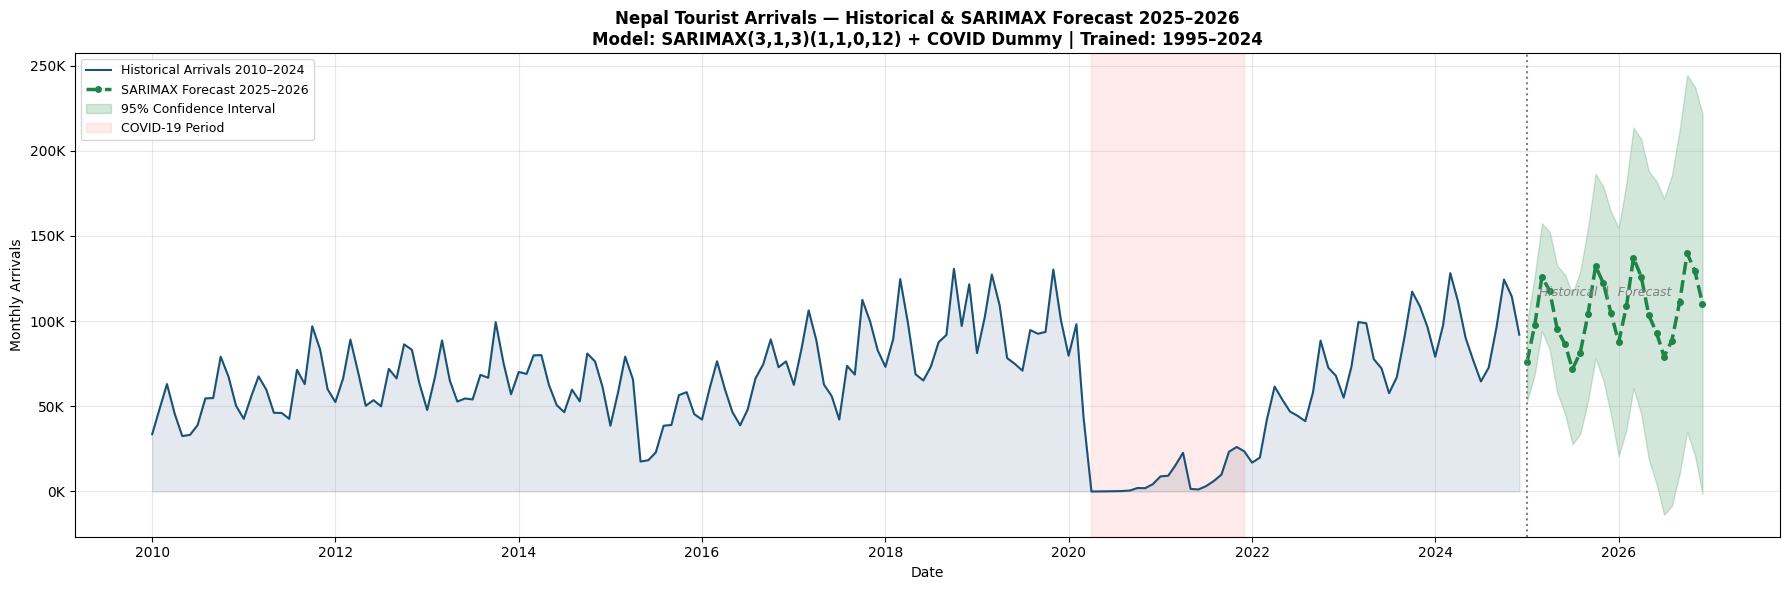

Graph saved


In [88]:
# Final forecast graph
fig, ax = plt.subplots(figsize=(18, 6))

historical = series['2010-01':]
ax.fill_between(historical.index, historical.values,
                alpha=0.12, color='#1a5276')
ax.plot(historical.index, historical.values,
        color='#1a5276', linewidth=1.5,
        label='Historical Arrivals 2010–2024')

ax.plot(future_mean.index, future_mean.values,
        color='#1e8449', linewidth=2.5,
        linestyle='--', marker='o', markersize=4,
        label='SARIMAX Forecast 2025–2026')
ax.fill_between(
    future_dates,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    alpha=0.20, color='#1e8449',
    label='95% Confidence Interval'
)

ax.axvline(pd.Timestamp('2025-01-01'),
           color='gray', linestyle=':', linewidth=1.5)
ax.text(pd.Timestamp('2025-02-01'),
        historical.max() * 0.88,
        ' Historical  |  Forecast ',
        fontsize=9, color='gray', style='italic')

ax.axvspan(pd.Timestamp('2020-04-01'),
           pd.Timestamp('2021-12-01'),
           alpha=0.08, color='red',
           label='COVID-19 Period')

ax.set_title(
    'Nepal Tourist Arrivals — Historical & '
    'SARIMAX Forecast 2025–2026\n'
    f'Model: SARIMAX({best_p_sx},1,{best_q_sx})'
    f'({best_P},1,{best_Q},12) + COVID Dummy | '
    f'Trained: 1995–2024',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Date')
ax.set_ylabel('Monthly Arrivals')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K')
)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('forecast_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph saved")

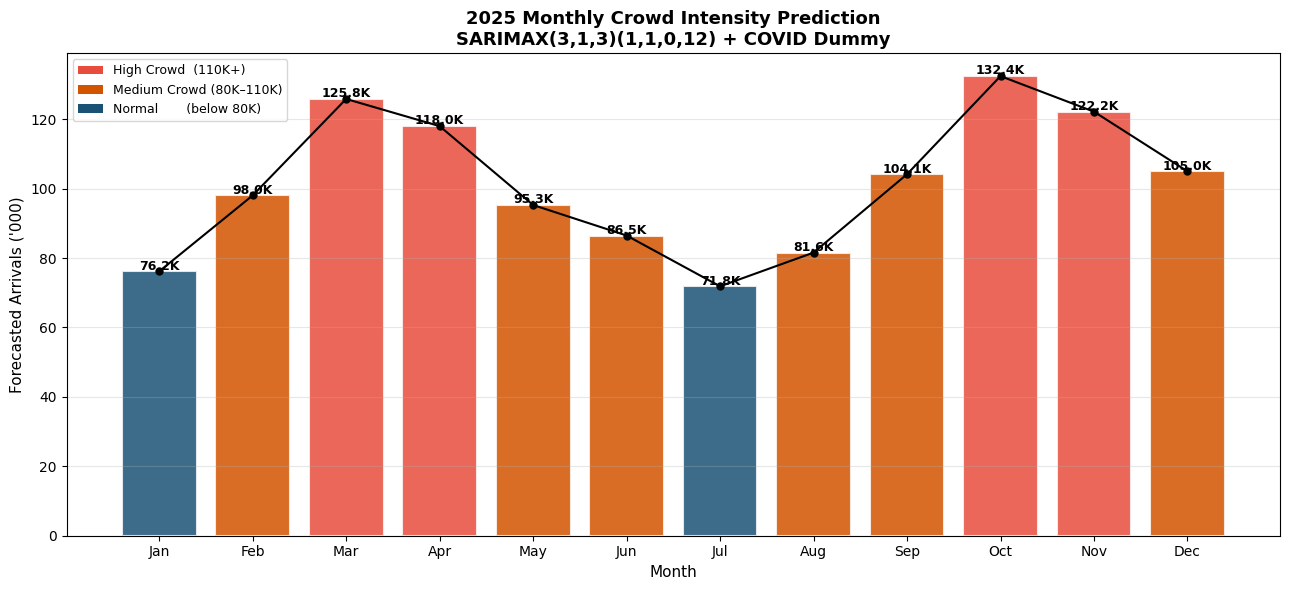

Graph saved


In [67]:
# 2025 monthly crowd prediction bar chart
forecast_2025 = future_mean['2025']

bar_colors = [
    '#e74c3c' if v >= 110000
    else '#d35400' if v >= 80000
    else '#1a5276'
    for v in forecast_2025.values
]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(
    month_names,
    forecast_2025.values / 1000,
    color=bar_colors, alpha=0.85,
    edgecolor='white', linewidth=1.5
)
ax.plot(month_names, forecast_2025.values / 1000,
        color='black', linewidth=1.5,
        marker='o', markersize=5)

for bar, val in zip(bars, forecast_2025.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val/1000:.1f}K',
        ha='center', fontsize=9, fontweight='bold'
    )

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#e74c3c', label='High Crowd  (110K+)'),
    Patch(facecolor='#d35400', label='Medium Crowd (80K–110K)'),
    Patch(facecolor='#1a5276', label='Normal       (below 80K)'),
], fontsize=9, loc='upper left')

ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel("Forecasted Arrivals ('000)", fontsize=11)
ax.set_title(
    '2025 Monthly Crowd Intensity Prediction\n'
    f'SARIMAX({best_p_sx},1,{best_q_sx})'
    f'({best_P},1,{best_Q},12) + COVID Dummy',
    fontsize=13, fontweight='bold'
)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('crowd_forecast_2025.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph saved")

**JSON FORMAT**

In [68]:
import json
import os

# A folder was made to keep all output files organized
os.makedirs('outputs', exist_ok=True)

print("Output folder created")
print("Now saving all results...")

Output folder created
Now saving all results...


**MODEL METRICS TO JSON FORMAT**

In [69]:

# SAVE MODEL METRICS
# These numbers go to the frontend
# to show the comparison table
metrics_data = {
    "test_period": {
        "start": "January 2023",
        "end": "December 2024",
        "months": len(test)
    },
    "models": {
        "ARIMA": {
            "order": f"({best_p},1,{best_q})",
            "MAE": round(float(arima_mae), 2),
            "RMSE": round(float(arima_rmse), 2),
            "MAPE": round(float(arima_mape), 2),
            "ljung_box_pvalue": round(float(lb_p_arima), 4),
            "residuals_random": bool(lb_p_arima > 0.05),
            "description": "Baseline model — captures trend only, no seasonality"
        },
        "SARIMAX": {
            "order": f"({best_p_sx},1,{best_q_sx})({best_P},1,{best_Q},12)",
            "MAE": round(float(sarimax_mae), 2),
            "RMSE": round(float(sarimax_rmse), 2),
            "MAPE": round(float(sarimax_mape), 2),
            "ljung_box_pvalue": round(float(lb_p_sarimax), 4),
            "residuals_random": bool(lb_p_sarimax > 0.05),
            "covid_dummy_included": True,
            "description": "Primary model — handles seasonality and COVID-19 intervention"
        }
    },
    "selected_model": "SARIMAX",
    "selection_reason": "Lower error metrics, passes Ljung-Box residual test, handles seasonality and COVID-19 dummy variable"
}

# Save to JSON file
with open('outputs/model_metrics.json', 'w') as f:
    json.dump(metrics_data, f, indent=4)

print("Saved: outputs/model_metrics.json")
print("\nPreview:")
print(json.dumps(metrics_data, indent=4))

Saved: outputs/model_metrics.json

Preview:
{
    "test_period": {
        "start": "January 2023",
        "end": "December 2024",
        "months": 24
    },
    "models": {
        "ARIMA": {
            "order": "(2,1,2)",
            "MAE": 18718.8,
            "RMSE": 23537.48,
            "MAPE": 18.56,
            "ljung_box_pvalue": 0.0,
            "residuals_random": false,
            "description": "Baseline model \u2014 captures trend only, no seasonality"
        },
        "SARIMAX": {
            "order": "(3,1,3)(1,1,0,12)",
            "MAE": 12022.64,
            "RMSE": 14885.99,
            "MAPE": 13.75,
            "ljung_box_pvalue": 0.2655,
            "residuals_random": true,
            "covid_dummy_included": true,
            "description": "Primary model \u2014 handles seasonality and COVID-19 intervention"
        }
    },
    "selected_model": "SARIMAX",
    "selection_reason": "Lower error metrics, passes Ljung-Box residual test, handles seasonality a

**2025 - 2026 FORECAST TO JSON**

In [70]:

# SAVE FORECAST RESULTS
# Monthly forecasts for 2025 and 2026
# with confidence intervals and crowd labels

month_names = ['Jan','Feb','Mar','Apr','May',
               'Jun','Jul','Aug','Sep','Oct','Nov','Dec']

def get_crowd_level(value):
    # Label each month's crowd intensity
    if value >= 110000:
        return "High"
    elif value >= 80000:
        return "Medium"
    else:
        return "Normal"

forecast_output = {
    "model_used": "SARIMAX",
    "model_order": f"({best_p_sx},1,{best_q_sx})({best_P},1,{best_Q},12)",
    "trained_on": "January 1995 to December 2024",
    "forecast_generated": "2025-2026",
    "forecast_2025": [],
    "forecast_2026": [],
    "annual_totals": {}
}

for yr in [2025, 2026]:
    annual_total = 0
    for date, val in future_mean[str(yr)].items():
        lo = conf_int.loc[date].iloc[0]
        hi = conf_int.loc[date].iloc[1]
        annual_total += val

        month_data = {
            "date": date.strftime('%Y-%m-%d'),
            "year": yr,
            "month": month_names[date.month - 1],
            "month_number": date.month,
            "forecast": round(float(val), 0),
            "lower_95": round(float(lo), 0),
            "upper_95": round(float(hi), 0),
            "crowd_level": get_crowd_level(float(val))
        }

        if yr == 2025:
            forecast_output["forecast_2025"].append(month_data)
        else:
            forecast_output["forecast_2026"].append(month_data)

    forecast_output["annual_totals"][str(yr)] = round(float(annual_total), 0)

with open('outputs/forecast_2025_2026.json', 'w') as f:
    json.dump(forecast_output, f, indent=4)

print("Saved: outputs/forecast_2025_2026.json")
print("\nPreview (first 3 months of 2025):")
print(json.dumps(forecast_output["forecast_2025"][:3], indent=4))
print("\nAnnual Totals:")
print(json.dumps(forecast_output["annual_totals"], indent=4))

Saved: outputs/forecast_2025_2026.json

Preview (first 3 months of 2025):
[
    {
        "date": "2025-01-01",
        "year": 2025,
        "month": "Jan",
        "month_number": 1,
        "forecast": 76151.0,
        "lower_95": 52961.0,
        "upper_95": 99340.0,
        "crowd_level": "Normal"
    },
    {
        "date": "2025-02-01",
        "year": 2025,
        "month": "Feb",
        "month_number": 2,
        "forecast": 98024.0,
        "lower_95": 69075.0,
        "upper_95": 126973.0,
        "crowd_level": "Medium"
    },
    {
        "date": "2025-03-01",
        "year": 2025,
        "month": "Mar",
        "month_number": 3,
        "forecast": 125812.0,
        "lower_95": 94223.0,
        "upper_95": 157401.0,
        "crowd_level": "High"
    }
]

Annual Totals:
{
    "2025": 1216749.0,
    "2026": 1314614.0
}


**HISTORICAL MONTHLY DATA TO JSON**

In [71]:

# SAVE HISTORICAL MONTHLY DATA
# Frontend uses this to draw the historical chart

historical_output = {
    "description": "Monthly tourist arrivals Nepal 1996-2024",
    "source": "Ministry of Culture Tourism and Civil Aviation Nepal",
    "data": []
}

for date, row in ts_df.iterrows():
    historical_output["data"].append({
        "date": date.strftime('%Y-%m-%d'),
        "year": date.year,
        "month": date.strftime('%b'),
        "month_number": date.month,
        "arrivals": round(float(row['Arrivals']), 0),
        "arrivals_smoothed": round(float(row['Arrivals_Smoothed']), 0),
        "covid_dummy": int(row['covid_dummy'])
    })

with open('outputs/historical_monthly.json', 'w') as f:
    json.dump(historical_output, f, indent=4)

print("Saved: outputs/historical_monthly.json")
print(f"Total records saved: {len(historical_output['data'])}")
print("\nPreview (first 2 records):")
print(json.dumps(historical_output["data"][:2], indent=4))

Saved: outputs/historical_monthly.json
Total records saved: 348

Preview (first 2 records):
[
    {
        "date": "1996-01-01",
        "year": 1996,
        "month": "Jan",
        "month_number": 1,
        "arrivals": 27886.0,
        "arrivals_smoothed": 27886.0,
        "covid_dummy": 0
    },
    {
        "date": "1996-02-01",
        "year": 1996,
        "month": "Feb",
        "month_number": 2,
        "arrivals": 29676.0,
        "arrivals_smoothed": 29676.0,
        "covid_dummy": 0
    }
]


**ANNUAL DATA TO JSON**

In [72]:

# SAVE ANNUAL DATA
# Frontend uses this to draw the yearly bar chart

annual_output = {
    "description": "Annual tourist arrivals Nepal 1996-2024",
    "data": []
}

for _, row in annual_df.iterrows():
    annual_output["data"].append({
        "year": int(row['Year']),
        "total": round(float(row['Total']), 0),
        "third_country": round(float(row['Third_Country']), 0),
        "indian": round(float(row['Indian']), 0),
        "pct_change": round(float(row['Pct_Change']), 2)
        if not pd.isna(row['Pct_Change']) else None
    })

with open('outputs/annual_arrivals.json', 'w') as f:
    json.dump(annual_output, f, indent=4)

print("Saved: outputs/annual_arrivals.json")
print(f"Total records saved: {len(annual_output['data'])}")
print("\nPreview:")
print(json.dumps(annual_output["data"][:3], indent=4))

Saved: outputs/annual_arrivals.json
Total records saved: 29

Preview:
[
    {
        "year": 1996,
        "total": 393613.0,
        "third_country": 271101.0,
        "indian": 122512.0,
        "pct_change": 8.3
    },
    {
        "year": 1997,
        "total": 421857.0,
        "third_country": 288419.0,
        "indian": 133438.0,
        "pct_change": 7.2
    },
    {
        "year": 1998,
        "total": 463684.0,
        "third_country": 320455.0,
        "indian": 143229.0,
        "pct_change": 9.9
    }
]


**CROWD HEATMAP DATA TO JSON**

In [73]:

# SAVE CROWD HEATMAP DATA
# Frontend uses this to draw the heatmap
# One record per year-month combination

month_cols_list = ['Jan','Feb','Mar','Apr','May','Jun',
                   'Jul','Aug','Sep','Oct','Nov','Dec']

heatmap_output = {
    "description": "Monthly arrival crowd intensity by year and month",
    "months": month_cols_list,
    "data": []
}

for _, row in monthly_df.iterrows():
    year = int(row['Year'])
    year_data = {
        "year": year,
        "monthly_arrivals": {}
    }
    for i, month in enumerate(month_cols_list, start=1):
        val = float(row[month]) if not pd.isna(row[month]) else 0
        year_data["monthly_arrivals"][month] = {
            "value": round(val, 0),
            "crowd_level": get_crowd_level(val)
        }
    heatmap_output["data"].append(year_data)

with open('outputs/heatmap_data.json', 'w') as f:
    json.dump(heatmap_output, f, indent=4)

print("Saved: outputs/heatmap_data.json")
print(f"Total year records: {len(heatmap_output['data'])}")
print("\nPreview (2024 data):")
last_year = heatmap_output["data"][-1]
print(f"Year: {last_year['year']}")
for month, info in last_year["monthly_arrivals"].items():
    print(f"  {month}: {info['value']:,.0f} — {info['crowd_level']}")

Saved: outputs/heatmap_data.json
Total year records: 29

Preview (2024 data):
Year: 2024
  Jan: 79,101 — Normal
  Feb: 97,423 — Medium
  Mar: 128,167 — High
  Apr: 111,382 — High
  May: 90,205 — Medium
  Jun: 76,733 — Normal
  Jul: 64,598 — Normal
  Aug: 72,717 — Normal
  Sep: 96,302 — Medium
  Oct: 124,391 — High
  Nov: 114,496 — High
  Dec: 92,033 — Medium


**PURPOSE OF VISIT TO JSON**

In [74]:

# SAVE PURPOSE OF VISIT DATA
# Frontend uses this for the purpose chart

purpose_output = {
    "description": "Tourist arrivals by purpose of visit 1996-2024",
    "data": []
}

for _, row in purpose_df.iterrows():
    purpose_output["data"].append({
        "year": int(row['Year']),
        "holiday": round(float(row['Holiday']), 0)
            if not pd.isna(row['Holiday']) else 0,
        "trekking": round(float(row['Trekking']), 0)
            if not pd.isna(row['Trekking']) else 0,
        "pilgrimage": round(float(row['Pilgrimage']), 0)
            if not pd.isna(row['Pilgrimage']) else 0,
        "business": round(float(row['Business']), 0)
            if not pd.isna(row['Business']) else 0,
        "official": round(float(row['Official']), 0)
            if not pd.isna(row['Official']) else 0,
        "coference": round(float(row['Conference']), 0)
            if not pd.isna(row['Conference']) else 0,
        "others": round(float(row['Others']), 0)
            if not pd.isna(row['Others']) else 0,
        "total": round(float(row['Total']), 0)
            if not pd.isna(row['Total']) else 0
    })

with open('outputs/purpose_of_visit.json', 'w') as f:
    json.dump(purpose_output, f, indent=4)

print("Saved: outputs/purpose_of_visit.json")
print(f"Total records: {len(purpose_output['data'])}")
print("\nPreview (last 2 years):")
print(json.dumps(purpose_output["data"][-2:], indent=4))

Saved: outputs/purpose_of_visit.json
Total records: 29

Preview (last 2 years):
[
    {
        "year": 2023,
        "holiday": 634301.0,
        "trekking": 154262.0,
        "pilgrimage": 132949.0,
        "business": 0.0,
        "official": 0.0,
        "coference": 0.0,
        "others": 93370.0,
        "total": 1014882.0
    },
    {
        "year": 2024,
        "holiday": 693119.0,
        "trekking": 166394.0,
        "pilgrimage": 175575.0,
        "business": 0.0,
        "official": 0.0,
        "coference": 0.0,
        "others": 112460.0,
        "total": 1147548.0
    }
]


**LENGTH OF STAY DATA TO JSON**

In [75]:

# SAVE LENGTH OF STAY DATA
# Frontend uses this for the stay duration chart

stay_output = {
    "description": "Average length of stay in days 1996-2024",
    "data": []
}

for _, row in stay_df.iterrows():
    stay_output["data"].append({
        "year": int(row['Year']),
        "total_arrivals": round(float(row['Total']), 0)
            if not pd.isna(row['Total']) else 0,
        "avg_stay_days": round(float(row['Avg_Stay_Days']), 2)
            if not pd.isna(row['Avg_Stay_Days']) else None,
        "by_air_number": round(float(row['By_Air_Number']), 0)
            if not pd.isna(row['By_Air_Number']) else 0,
        "by_land_number": round(float(row['By_Land_Number']), 0)
            if not pd.isna(row['By_Land_Number']) else 0,
        "by_air_pct": round(float(row['By_Air_Pct']), 1)
            if not pd.isna(row['By_Air_Pct']) else None,
        "by_land_pct": round(float(row['By_Land_Pct']), 1)
            if not pd.isna(row['By_Land_Pct']) else None
    })

with open('outputs/length_of_stay.json', 'w') as f:
    json.dump(stay_output, f, indent=4)

print("Saved: outputs/length_of_stay.json")
print(f"Total records: {len(stay_output['data'])}")
print("\nPreview (last 3 years):")
print(json.dumps(stay_output["data"][-3:], indent=4))

Saved: outputs/length_of_stay.json
Total records: 29

Preview (last 3 years):
[
    {
        "year": 2022,
        "total_arrivals": 614869.0,
        "avg_stay_days": 13.1,
        "by_air_number": 592631.0,
        "by_land_number": 22238.0,
        "by_air_pct": 96.4,
        "by_land_pct": 3.6
    },
    {
        "year": 2023,
        "total_arrivals": 1014882.0,
        "avg_stay_days": 13.2,
        "by_air_number": 914270.0,
        "by_land_number": 100612.0,
        "by_air_pct": 90.1,
        "by_land_pct": 9.9
    },
    {
        "year": 2024,
        "total_arrivals": 1147548.0,
        "avg_stay_days": 13.3,
        "by_air_number": 1023937.0,
        "by_land_number": 123611.0,
        "by_air_pct": 89.2,
        "by_land_pct": 10.8
    }
]


**ADF STATIONARITY RESULTS TO JSON**

In [76]:
import scipy.stats as scipy_stats
from statsmodels.tsa.stattools import adfuller

# Re-calculate p-values for differenced series as they were not explicitly stored
p1 = adfuller(series.dropna(), autolag='AIC')[1]
p2 = adfuller(series_diff1.dropna(), autolag='AIC')[1]
p3 = adfuller(series_diff_s.dropna(), autolag='AIC')[1]
p4 = adfuller(series_diff_both.dropna(), autolag='AIC')[1]

# SAVE STATIONARITY TEST RESULTS

stationarity_output = {
    "test": "Augmented Dickey-Fuller (ADF)",
    "significance_level": 0.05,
    "rule": "p-value < 0.05 means STATIONARY",
    "results": {
        "original_series": {
            "label": "Original Smoothed Series",
            "adf_statistic": round(float(
                adfuller(series.dropna(), autolag='AIC')[0]
            ), 4),
            "p_value": round(float(p1), 6),
            "is_stationary": bool(stat1),
            "note": "Passes ADF test but visual trend present — d=1 still applied"
        },
        "first_differenced": {
            "label": "First Differenced (d=1)",
            "p_value": round(p2, 6),
            "is_stationary": bool(stat2)
        },
        "seasonal_differenced": {
            "label": "Seasonal Differenced (D=1, s=12)",
            "p_value": round(p3, 6),
            "is_stationary": bool(stat3)
        },
        "both_differenced": {
            "label": "Seasonal + First Differenced (d=1, D=1)",
            "p_value": round(p4, 6),
            "is_stationary": bool(stat4)
        }
    },
    "decision": {
        "d": 1,
        "D": 1,
        "s": 12
    }
}

with open('outputs/stationarity_results.json', 'w') as f:
    json.dump(stationarity_output, f, indent=4)

print("Saved: outputs/stationarity_results.json")
print("\nPreview:")
print(json.dumps(stationarity_output, indent=4))

Saved: outputs/stationarity_results.json

Preview:
{
    "test": "Augmented Dickey-Fuller (ADF)",
    "significance_level": 0.05,
    "rule": "p-value < 0.05 means STATIONARY",
    "results": {
        "original_series": {
            "label": "Original Smoothed Series",
            "adf_statistic": -3.6889,
            "p_value": 0.004272,
            "is_stationary": true,
            "note": "Passes ADF test but visual trend present \u2014 d=1 still applied"
        },
        "first_differenced": {
            "label": "First Differenced (d=1)",
            "p_value": 0.001715,
            "is_stationary": true
        },
        "seasonal_differenced": {
            "label": "Seasonal Differenced (D=1, s=12)",
            "p_value": 0.001668,
            "is_stationary": true
        },
        "both_differenced": {
            "label": "Seasonal + First Differenced (d=1, D=1)",
            "p_value": 0.0,
            "is_stationary": true
        }
    },
    "decision": {
      

**OUTLIER DETECTION RESULTS TO JSON**

In [77]:

# SAVE OUTLIER DETECTION RESULTS
outliers_list = []
for i, (date, val) in enumerate(arrivals[outlier_mask].items()):
    z = z_scores_series.loc[date]
    outliers_list.append({
        "date": date.strftime('%Y-%m-%d'),
        "month_year": date.strftime('%B %Y'),
        "original_value": round(float(val), 0),
        "replaced_with": round(float(rolling_median[date]), 0),
        "z_score": round(float(z), 2)
    })

outlier_output = {
    "method": "Z-Score",
    "threshold": 3.0,
    "total_months_checked": int(len(arrivals)),
    "outliers_found": int(outlier_mask.sum()),
    "replacement_method": "12-month rolling median",
    "outliers": outliers_list
}

with open('outputs/outlier_detection.json', 'w') as f:
    json.dump(outlier_output, f, indent=4)

print("Saved: outputs/outlier_detection.json")
print("\nPreview:")
print(json.dumps(outlier_output, indent=4))

Saved: outputs/outlier_detection.json

Preview:
{
    "method": "Z-Score",
    "threshold": 3.0,
    "total_months_checked": 348,
    "outliers_found": 2,
    "replacement_method": "12-month rolling median",
    "outliers": [
        {
            "date": "2018-11-01",
            "month_year": "November 2018",
            "original_value": 147859.0,
            "replaced_with": 97148.0,
            "z_score": 3.51
        },
        {
            "date": "2019-10-01",
            "month_year": "October 2019",
            "original_value": 134096.0,
            "replaced_with": 93676.0,
            "z_score": 3.02
        }
    ]
}


**SUMMARY JSON**

In [78]:

# MASTER SUMMARY FILE
# Backend can load this single file
# to get a complete overview of the project

master_summary = {
    "project": "Web-Based Tourism Flow Analysis with Time-Series Forecasting",
    "group": "Group 26",

    "dataset_info": {
        "source": "Ministry of Culture Tourism and Civil Aviation Nepal",
        "total_years": "1996 to 2024",
        "monthly_observations": int(len(ts_df)),
        "outliers_detected": int(outlier_mask.sum()),
        "covid_months_marked": int(ts_df['covid_dummy'].sum())
    },

    "model_training": {
        "train_period": "January 1995 to December 2022",
        "test_period": "January 2023 to December 2024",
        "train_months": int(len(train)),
        "test_months": int(len(test))
    },

    "best_model": {
        "name": "SARIMAX",
        "order": f"({best_p_sx},1,{best_q_sx})({best_P},1,{best_Q},12)",
        "MAE": round(float(sarimax_mae), 2),
        "RMSE": round(float(sarimax_rmse), 2),
        "MAPE": round(float(sarimax_mape), 2),
        "residuals_random": bool(lb_p_sarimax > 0.05),
        "covid_dummy": True
    },

    "arima_model": {
        "name": "ARIMA",
        "order": f"({best_p},1,{best_q})",
        "MAE": round(float(arima_mae), 2),
        "RMSE": round(float(arima_rmse), 2),
        "MAPE": round(float(arima_mape), 2),
        "residuals_random": bool(lb_p_arima > 0.05)
    },

    "forecast_summary": {
        "2025": {
            "total": round(float(future_mean['2025'].sum()), 0),
            "peak_month": month_names[
                future_mean['2025'].values.argmax()
            ],
            "peak_value": round(float(future_mean['2025'].max()), 0),
            "lowest_month": month_names[
                future_mean['2025'].values.argmin()
            ],
            "lowest_value": round(float(future_mean['2025'].min()), 0)
        },
        "2026": {
            "total": round(float(future_mean['2026'].sum()), 0),
            "peak_month": month_names[
                future_mean['2026'].values.argmax()
            ],
            "peak_value": round(float(future_mean['2026'].max()), 0),
            "lowest_month": month_names[
                future_mean['2026'].values.argmin()
            ],
            "lowest_value": round(float(future_mean['2026'].min()), 0)
        }
    },

    "output_files": {
        "forecast": "forecast_2025_2026.json",
        "metrics": "model_metrics.json",
        "historical": "historical_monthly.json",
        "annual": "annual_arrivals.json",
        "heatmap": "heatmap_data.json",
        "purpose": "purpose_of_visit.json",
        "stay": "length_of_stay.json",
        "stationarity": "stationarity_results.json",
        "outliers": "outlier_detection.json"
    }
}

with open('outputs/master_summary.json', 'w') as f:
    json.dump(master_summary, f, indent=4)

print("Saved: outputs/master_summary.json")
print("\nPreview:")
print(json.dumps(master_summary, indent=4))

Saved: outputs/master_summary.json

Preview:
{
    "project": "Web-Based Tourism Flow Analysis with Time-Series Forecasting",
    "group": "Group 26",
    "dataset_info": {
        "source": "Ministry of Culture Tourism and Civil Aviation Nepal",
        "total_years": "1996 to 2024",
        "monthly_observations": 348,
        "outliers_detected": 2,
        "covid_months_marked": 21
    },
    "model_training": {
        "train_period": "January 1995 to December 2022",
        "test_period": "January 2023 to December 2024",
        "train_months": 324,
        "test_months": 24
    },
    "best_model": {
        "name": "SARIMAX",
        "order": "(3,1,3)(1,1,0,12)",
        "MAE": 12022.64,
        "RMSE": 14885.99,
        "MAPE": 13.75,
        "residuals_random": true,
        "covid_dummy": true
    },
    "arima_model": {
        "name": "ARIMA",
        "order": "(2,1,2)",
        "MAE": 18718.8,
        "RMSE": 23537.48,
        "MAPE": 18.56,
        "residuals_random": fa

**PRINTED SAVE FILES**

In [79]:

print("  ALL FILES SAVED SUCCESSFULLY")


import os
output_files = os.listdir('outputs')
output_files.sort()

print("\nJSON files (for backend/frontend):")
for f in output_files:
    if f.endswith('.json'):
        size = os.path.getsize(f'outputs/{f}')
        print(f"  outputs/{f}  ({size:,} bytes)")

print("\nCSV files (backup):")
for f in output_files:
    if f.endswith('.csv'):
        size = os.path.getsize(f'outputs/{f}')
        print(f"  outputs/{f}  ({size:,} bytes)")

print("\n" )
print("  HOW BACKEND USES THESE FILES")
print("""
  1. Backend reads master_summary.json (gets overview of everything)
  2. Backend reads forecast_2025_2026.json (sends monthly predictions to frontend chart)
  3. Backend reads model_metrics.json (sends MAE RMSE MAPE to frontend table)
  4. Backend reads historical_monthly.json (sends historical data to frontend line chart)
  5. Backend reads heatmap_data.json (sends crowd intensity to frontend heatmap)
  6. All files are ready to serve via REST API (backend just does: response.json(data))
""")

  ALL FILES SAVED SUCCESSFULLY

JSON files (for backend/frontend):
  outputs/annual_arrivals.json  (5,294 bytes)
  outputs/forecast_2025_2026.json  (6,925 bytes)
  outputs/heatmap_data.json  (46,838 bytes)
  outputs/historical_monthly.json  (85,140 bytes)
  outputs/length_of_stay.json  (7,770 bytes)
  outputs/master_summary.json  (1,829 bytes)
  outputs/model_metrics.json  (985 bytes)
  outputs/outlier_detection.json  (591 bytes)
  outputs/purpose_of_visit.json  (8,944 bytes)
  outputs/stationarity_results.json  (998 bytes)

CSV files (backup):


  HOW BACKEND USES THESE FILES

  1. Backend reads master_summary.json (gets overview of everything)
  2. Backend reads forecast_2025_2026.json (sends monthly predictions to frontend chart)
  3. Backend reads model_metrics.json (sends MAE RMSE MAPE to frontend table)
  4. Backend reads historical_monthly.json (sends historical data to frontend line chart)
  5. Backend reads heatmap_data.json (sends crowd intensity to frontend heatmap)
  6. All

In [80]:
from google.colab import files
import zipfile

# Zip all output files into one file for easy download
with zipfile.ZipFile('all_outputs.zip', 'w') as zipf:
    for f in os.listdir('outputs'):
        zipf.write(f'outputs/{f}', f)

print("Created: all_outputs.zip")

# Download the zip
files.download('all_outputs.zip')
print("Downloaded: all_outputs.zip")

Created: all_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: all_outputs.zip


In [81]:
import pickle
import os



In [82]:
import os

# Create the directory if it doesn't exist
os.makedirs('pkl_outputs', exist_ok=True)

# ─────────────────────────
# SAVE ARIMA MODEL
# Backend loads this and calls .forecast()
# ─────────────────────────

with open('pkl_outputs/arima_model.pkl', 'wb') as f:
    pickle.dump(arima_fit, f)

print("Saved: pkl_outputs/arima_model.pkl")

# Verify it saved correctly by loading it back
with open('pkl_outputs/arima_model.pkl', 'rb') as f:
    arima_loaded = pickle.load(f)

# Test it produces same forecast
test_forecast = arima_loaded.forecast(steps=3)
print("Verification — ARIMA produces forecast:", test_forecast.values)
print("ARIMA pkl file working correctly ✓")

Saved: pkl_outputs/arima_model.pkl
Verification — ARIMA produces forecast: [64078.9043857  68942.14868636 77614.15049004]
ARIMA pkl file working correctly ✓


In [83]:
# ─────────────────────────────────────────────
# SAVE SARIMAX MODEL (Primary Model)
# This is the most important pkl file
# Backend uses this for live forecasting
# ─────────────────────────────────────────────

with open('pkl_outputs/sarimax_model.pkl', 'wb') as f:
    pickle.dump(sarimax_fit, f)

print("Saved: pkl_outputs/sarimax_model.pkl")

# Verify it saved correctly
with open('pkl_outputs/sarimax_model.pkl', 'rb') as f:
    sarimax_loaded = pickle.load(f)

# Test it produces forecast
# Need dummy = 0 for future months (no COVID)
test_dummy_verify = pd.Series(
    [0, 0, 0],
    index=pd.date_range(start='2025-01-01', periods=3, freq='MS')
)
test_forecast_sx = sarimax_loaded.forecast(
    steps=3, exog=test_dummy_verify
)
print("Verification — SARIMAX produces forecast:", test_forecast_sx.values)
print("SARIMAX pkl file working correctly ✓")

Saved: pkl_outputs/sarimax_model.pkl
Verification — SARIMAX produces forecast: [57865.48526684 61850.34220891 76178.39096243]
SARIMAX pkl file working correctly ✓


In [84]:
# ─────────────────────────────────────────────
# SAVE FINAL MODEL
# This is retrained on ALL data 1995-2024
# Backend uses this when user requests
# any custom forecast period
# ─────────────────────────────────────────────

with open('pkl_outputs/sarimax_final_model.pkl', 'wb') as f:
    pickle.dump(final_fit, f)

print("Saved: pkl_outputs/sarimax_final_model.pkl")

# Verify
with open('pkl_outputs/sarimax_final_model.pkl', 'rb') as f:
    final_loaded = pickle.load(f)

# Test 12 month forecast
future_dummy_test = pd.Series(
    0,
    index=pd.date_range(start='2025-01-01', periods=12, freq='MS')
)
test_final_forecast = final_loaded.forecast(
    steps=12, exog=future_dummy_test
)
print("\nVerification — Final model 2025 forecast:")
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
for i, (date, val) in enumerate(test_final_forecast.items()):
    print(f"  {month_names[i]} 2025: {val:,.0f}")
print("\nFinal SARIMAX pkl working correctly ✓")

Saved: pkl_outputs/sarimax_final_model.pkl

Verification — Final model 2025 forecast:
  Jan 2025: 76,151
  Feb 2025: 98,024
  Mar 2025: 125,812
  Apr 2025: 117,983
  May 2025: 95,267
  Jun 2025: 86,475
  Jul 2025: 71,841
  Aug 2025: 81,559
  Sep 2025: 104,125
  Oct 2025: 132,396
  Nov 2025: 122,151
  Dec 2025: 104,965

Final SARIMAX pkl working correctly ✓


In [85]:
# ── DOWNLOAD BOTH PKL FILES ──────────────────
from google.colab import files

files.download('pkl_outputs/arima_model.pkl')
files.download('pkl_outputs/sarimax_final_model.pkl')

print("Both pkl files downloaded")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Both pkl files downloaded
